# 🧠 Convolutional Neural Networks — A Complete Educational Journey

> **From the convolution operator to modern image classification, end-to-end in PyTorch.**

This notebook is designed as a **self-contained course**. Run the cells top-to-bottom and you will go from "what is a convolution?" to fine-tuning state-of-the-art models, with every intermediate concept explained and visualized.

## 🛤️ Roadmap

| Part | Topic |
|------|-------|
| **A. Foundations** | |
| 1 | Setup, GPU check, reproducibility |
| 2 | The convolution operator — intuitive, visual, hand-coded |
| 3 | Strides, padding, dilation, receptive fields |
| 4 | Pooling, activations, batch normalization |
| 5 | From a single conv to a full CNN block |
| **B. Training fundamentals** | |
| 6 | Datasets: train / validation / test splits — *why* and *how* |
| 7 | Preprocessing & normalization (per-image, per-channel, ImageNet stats) |
| 8 | Data augmentation (classic + Mixup/CutMix/RandAugment/TrivialAugment) |
| 9 | Loss functions (CE, label smoothing, focal, BCE) |
| 10 | Optimizers (SGD/momentum, Adam, AdamW) |
| 11 | Learning-rate schedules, weight decay, gradient clipping |
| **C. Build & train your first CNN** | |
| 12 | A small CNN on CIFAR-10 — full training loop, plots, analysis |
| 13 | Hyperparameter taxonomy + manual sensitivity analysis |
| 14 | Hyperparameter tuning with **Optuna** |
| 15 | **K-fold cross-validation** |
| **D. Classic & modern architectures** | |
| 16 | LeNet → AlexNet → VGG (the depth race) |
| 17 | Inception (multi-branch), ResNet (skip connections) |
| 18 | DenseNet, MobileNet (depthwise sep. convs), EfficientNet |
| 19 | Vision Transformers (ViT) and ConvNeXt — modern SOTA |
| **E. Practical workflows** | |
| 20 | Transfer learning & fine-tuning |
| 21 | **t-SNE** of learned features — what does the network represent? |
| 22 | **Grad-CAM** — which pixels did the network look at? |
| 23 | Inference benchmarking (latency, throughput, FLOPs, params) |
| 24 | Best practices, common pitfalls, robotics/CV applications |

## 📌 How to use this notebook

- **Hardware**: Colab → `Runtime → Change runtime type → GPU` (T4 is enough). All code falls back to CPU but is much slower there.
- **Order matters**: later sections reuse helpers and trained models from earlier ones.
- **No uploads required**: everything trains on CIFAR-10 (auto-downloaded by torchvision).
- **Time budget**: ~20-40 minutes on a T4 GPU to run *all* training cells; quicker if you reduce epochs as suggested in each section.

## 🤖 Robotics & CV connection

CNN-based image classification is the perception backbone of robotics:
- Recognizing objects to grasp
- Place recognition for SLAM (loop closure)
- Terrain classification for legged robots
- Quality inspection on assembly lines
- Gesture / face recognition for HRI

We'll point out concrete robotics relevance as we go.


---
# Part A — Foundations

We start with the building block of every CNN: the **convolution operator**. Before we touch PyTorch's `nn.Conv2d`, we'll implement convolution by hand and see what each component *does*.


## 1. 🛠️ Setup, GPU Check, Reproducibility

**Reproducibility is non-negotiable in research.** We seed every random source PyTorch / NumPy / CUDA can touch, and print the exact environment so anyone re-running this notebook gets comparable results.


In [ ]:
# Colab usually has PyTorch installed. We just install Optuna & timm extras here.
!pip install -q optuna timm torchinfo grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.3 MB/s eta 0:00:00


In [ ]:
import os, sys, time, math, random, copy, json, warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['figure.dpi'] = 90
plt.rcParams['figure.figsize'] = (8, 5)

# ------------------------------------------------------------------
# Reproducibility utilities
# ------------------------------------------------------------------
def seed_everything(seed: int = 42):
    """Seed every random source we touch. Call at the top of any experiment."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # The two lines below guarantee determinism but slow training a bit; toggle off for production.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)

seed_everything(42)

# ------------------------------------------------------------------
# Device selection — PyTorch idiom
# ------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 60)
print(f'Python      : {sys.version.split()[0]}')
print(f'PyTorch     : {torch.__version__}')
print(f'TorchVision : {torchvision.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Device      : {device}')
if device.type == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'CUDA        : {torch.version.cuda}')
    print(f'cuDNN       : {torch.backends.cudnn.version()}')
print('=' * 60)


Python      : 3.12.13
PyTorch     : 2.10.0+cu128
TorchVision : 0.25.0+cu128
NumPy       : 2.0.2
Device      : cuda
GPU         : Tesla T4
CUDA        : 12.8
cuDNN       : 91002


## 2. 🔍 The Convolution Operator — Intuition First

A 2D convolution is a deceptively simple recipe:

> **Slide a small window (the *kernel*) across the image. At each position, multiply the kernel values with the underlying image patch, sum the results, and write that sum into an output map.**

That single operation is what makes CNNs work. By **learning** the kernel values, the network discovers what local patterns are useful for the task — edges, corners, textures, eventually whole object parts.

### Mathematical form (single channel, no padding, stride 1)

For an input image $X$ of size $H \times W$ and a kernel $K$ of size $k_h \times k_w$:

$$ Y[i, j] = \sum_{u=0}^{k_h - 1} \sum_{v=0}^{k_w - 1} X[i+u, j+v] \cdot K[u, v] $$

### A note on "convolution" vs "cross-correlation"

Mathematicians flip the kernel before sliding it. Deep-learning frameworks **don't** — they actually compute cross-correlation. Since the kernel is learned anyway, the flip is irrelevant in practice. Everyone calls the operation "convolution" regardless.


### 2.1 Hand-coded convolution

Let's implement a 2D convolution from scratch using only NumPy, then compare with PyTorch's optimized version. This is the best way to *internalize* what's happening.


In [ ]:
def conv2d_naive(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Pure-NumPy 2D convolution (actually cross-correlation), no padding, stride 1."""
    H, W      = image.shape
    kh, kw    = kernel.shape
    out_h     = H - kh + 1
    out_w     = W - kw + 1
    out       = np.zeros((out_h, out_w), dtype=np.float32)
    for i in range(out_h):
        for j in range(out_w):
            patch     = image[i:i+kh, j:j+kw]
            out[i, j] = (patch * kernel).sum()
    return out

# A small synthetic image we can visualize easily
img = np.zeros((9, 9), dtype=np.float32)
img[3:6, 3:6] = 1.0     # a white square in the middle
print("Input image (1 = white):")
print(img)

# Three classic 3x3 kernels
KERNELS = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    'Sobel-X (vertical edges)': np.array([[-1, 0, 1],
                                            [-2, 0, 2],
                                            [-1, 0, 1]], dtype=np.float32),
    'Sobel-Y (horizontal edges)': np.array([[-1, -2, -1],
                                              [ 0,  0,  0],
                                              [ 1,  2,  1]], dtype=np.float32),
    'Box blur': np.ones((3, 3), dtype=np.float32) / 9.0,
}

print(f"\nOutput shape for 9x9 input with 3x3 kernel: "
      f"{conv2d_naive(img, KERNELS['Identity']).shape} = (9-3+1) x (9-3+1)")


Input image (1 = white):
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Output shape for 9x9 input with 3x3 kernel: (7, 7) = (9-3+1) x (9-3+1)


Real image: shape=(512, 512), dtype=float32, range=[0.00, 1.00]


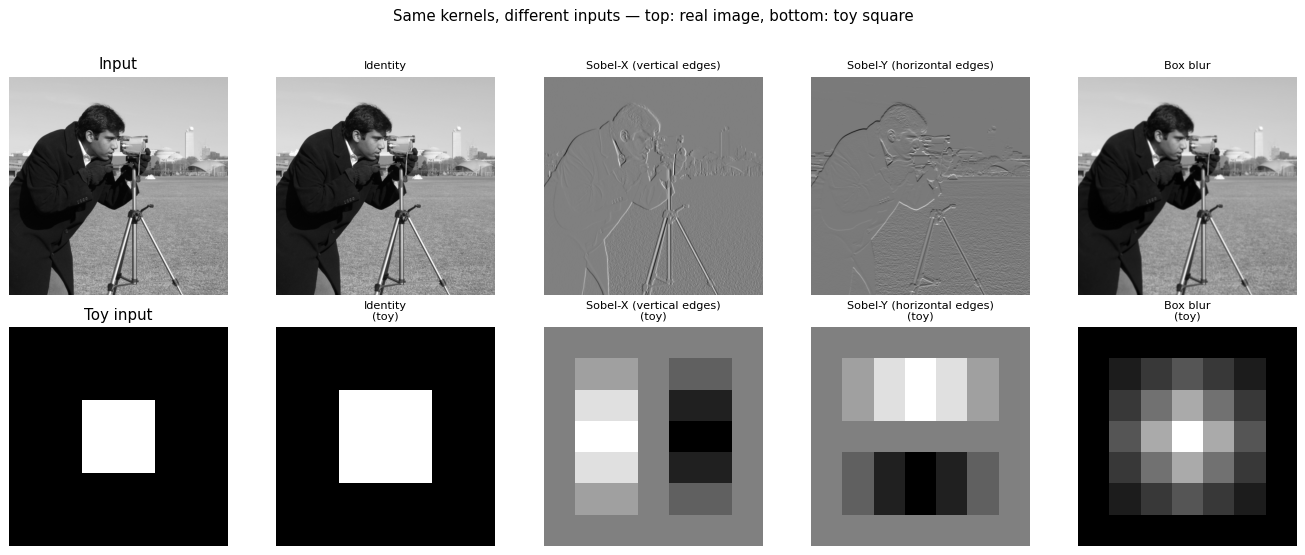

In [ ]:
# Visualize the effect of each kernel
fig, axes = plt.subplots(2, len(KERNELS) + 1, figsize=(15, 6))

# Use a real image so the edge filters look meaningful
from skimage import data
real = data.camera().astype(np.float32) / 255.0
print(f"Real image: shape={real.shape}, dtype={real.dtype}, range=[{real.min():.2f}, {real.max():.2f}]")

axes[0, 0].imshow(real, cmap='gray'); axes[0, 0].set_title('Input'); axes[0, 0].axis('off')
axes[1, 0].imshow(img,  cmap='gray'); axes[1, 0].set_title('Toy input'); axes[1, 0].axis('off')

for col, (name, K) in enumerate(KERNELS.items(), start=1):
    out_real = conv2d_naive(real, K)
    out_toy  = conv2d_naive(img,  K)
    axes[0, col].imshow(out_real, cmap='gray')
    axes[0, col].set_title(name, fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(out_toy, cmap='gray')
    axes[1, col].set_title(f'{name}\n(toy)', fontsize=9); axes[1, col].axis('off')

plt.suptitle('Same kernels, different inputs — top: real image, bottom: toy square', y=1.02)
plt.tight_layout(); plt.show()


**🔎 Observe:**

- The **identity** kernel returns the input unchanged.
- **Sobel-X** highlights vertical edges (left-right intensity changes).
- **Sobel-Y** highlights horizontal edges.
- The **box blur** averages neighborhoods → smooths the image.

These hand-crafted filters used to be the entire computer-vision pipeline (think classical edge detection, SIFT, HOG features). **The leap of CNNs is that the network *learns* the kernel values from data**, instead of an engineer designing them by hand.


### 2.2 Verifying against PyTorch's `nn.Conv2d`

PyTorch expects 4D tensors: **(batch, channels, height, width)** — `BCHW`. We unsqueeze our 2D image twice to add the batch and channel dimensions.


In [ ]:
# Convert NumPy -> tensor in BCHW layout
img_tensor = torch.from_numpy(real).unsqueeze(0).unsqueeze(0)   # [1, 1, H, W]
print(f"Input tensor shape (BCHW): {img_tensor.shape}")

# Wrap one of our kernels as the weight of an nn.Conv2d layer
sobel = torch.from_numpy(KERNELS['Sobel-X (vertical edges)']).unsqueeze(0).unsqueeze(0)
print(f"Kernel tensor shape (out_ch, in_ch, kh, kw): {sobel.shape}")

# Use the functional form (no learnable parameters needed for this demo)
out_torch = F.conv2d(img_tensor, sobel)  # default stride=1, padding=0
out_numpy = conv2d_naive(real, KERNELS['Sobel-X (vertical edges)'])

print(f"\nPyTorch output shape : {out_torch.shape}")
print(f"NumPy output shape    : {out_numpy.shape}")
print(f"Max absolute difference: {np.abs(out_torch.numpy().squeeze() - out_numpy).max():.2e}")
print("→ Identical. PyTorch is just a fast, batched, GPU-aware version of the same recipe.")


Input tensor shape (BCHW): torch.Size([1, 1, 512, 512])
Kernel tensor shape (out_ch, in_ch, kh, kw): torch.Size([1, 1, 3, 3])

PyTorch output shape : torch.Size([1, 1, 510, 510])
NumPy output shape    : (510, 510)
Max absolute difference: 4.77e-07
→ Identical. PyTorch is just a fast, batched, GPU-aware version of the same recipe.


## 3. 📏 Strides, Padding, Dilation, and Receptive Fields

### 3.1 Three knobs that change the output size

For an input of size $H \times W$, kernel size $k$, stride $s$, padding $p$, and dilation $d$:

$$ \text{out} = \left\lfloor \frac{H + 2p - d(k - 1) - 1}{s} \right\rfloor + 1 $$

| Knob | Effect | Why you'd use it |
|------|--------|------------------|
| **Stride** $s$ | Step size of the sliding window | Downsample (replace pooling) |
| **Padding** $p$ | Pixels added to the border | Preserve spatial size; avoid losing the borders |
| **Dilation** $d$ | Spacing inside the kernel | Enlarge the receptive field cheaply (used in segmentation) |


In [ ]:
def out_size(H, k, s=1, p=0, d=1):
    return (H + 2*p - d*(k - 1) - 1) // s + 1

# Common setups
print(f"{'Setup':<60} -> output (input 32x32)")
print("-" * 80)
for cfg in [
    dict(k=3, s=1, p=0, d=1),
    dict(k=3, s=1, p=1, d=1),  # 'same' padding for 3x3 convs
    dict(k=3, s=2, p=1, d=1),  # downsample by 2 (very common!)
    dict(k=5, s=1, p=2, d=1),  # 5x5 with same padding
    dict(k=3, s=1, p=2, d=2),  # dilation 2 → bigger receptive field
    dict(k=7, s=2, p=3, d=1),  # ResNet's stem
]:
    o = out_size(32, **cfg)
    print(f"k={cfg['k']}, stride={cfg['s']}, padding={cfg['p']}, dilation={cfg['d']:<3} -> {o}x{o}")


Setup                                                        -> output (input 32x32)
--------------------------------------------------------------------------------
k=3, stride=1, padding=0, dilation=1   -> 30x30
k=3, stride=1, padding=1, dilation=1   -> 32x32
k=3, stride=2, padding=1, dilation=1   -> 16x16
k=5, stride=1, padding=2, dilation=1   -> 32x32
k=3, stride=1, padding=2, dilation=2   -> 32x32
k=7, stride=2, padding=3, dilation=1   -> 16x16


### 3.2 Visualizing strides

A stride of 2 effectively *downsamples* the feature map by 2× while letting the kernel see twice as much area per output unit. **Most modern CNNs use stride-2 convs (or pools) at a few key points to build a hierarchical pyramid of features.**


Input stripes: (12, 12)


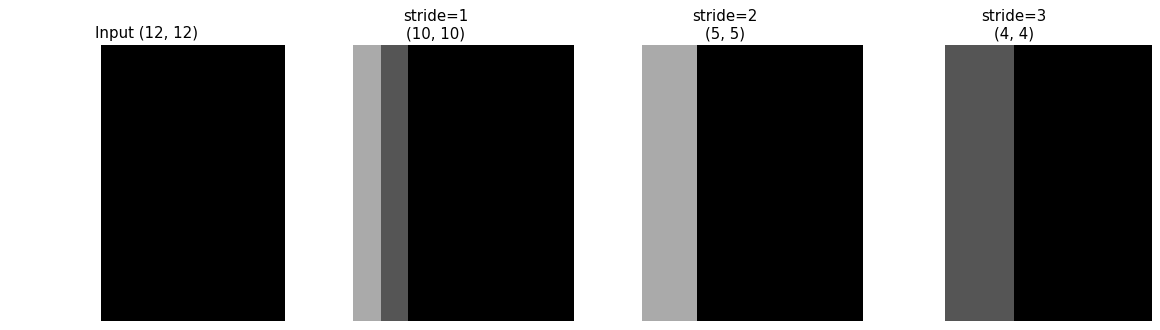

In [ ]:
# Build a simple striped image and apply a 3x3 averaging filter at strides 1, 2, 3
stripes = np.tile(np.array([1, 0, 0]).repeat(4), (12, 4))[:, :12].astype(np.float32)
print(f"Input stripes: {stripes.shape}")

filt = np.ones((3, 3), dtype=np.float32) / 9.0

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
axes[0].imshow(stripes, cmap='gray'); axes[0].set_title(f'Input {stripes.shape}'); axes[0].axis('off')

for i, s in enumerate([1, 2, 3], start=1):
    t = torch.from_numpy(stripes).unsqueeze(0).unsqueeze(0)
    K = torch.from_numpy(filt).unsqueeze(0).unsqueeze(0)
    o = F.conv2d(t, K, stride=s).squeeze().numpy()
    axes[i].imshow(o, cmap='gray')
    axes[i].set_title(f'stride={s}\n{o.shape}')
    axes[i].axis('off')

plt.tight_layout(); plt.show()


### 3.3 Receptive field — what each output sees

The **receptive field** of a unit is the region of the *original input* that influences its value. As we stack convolutions, the receptive field grows — eventually covering the whole image, which is why deep networks can reason about global structure.

For a stack of conv layers with kernel sizes $k_i$ and strides $s_i$, the receptive field after layer $L$ is:

$$ RF_L = 1 + \sum_{i=1}^{L} \left( (k_i - 1) \prod_{j=1}^{i-1} s_j \right) $$


In [ ]:
def receptive_field(layers):
    """Compute receptive field for a list of (kernel, stride) tuples."""
    rf, jump = 1, 1
    for k, s in layers:
        rf   += (k - 1) * jump
        jump *= s
    return rf

# Compare: 3 layers of 3x3 conv (s=1) vs a single 7x7 conv
print(f"3 stacked 3x3 convs (s=1)  : RF = {receptive_field([(3,1)] * 3)}")
print(f"1 single  7x7 conv        : RF = {receptive_field([(7,1)])}")
print("Both have a 7x7 receptive field, but 3 layers of 3x3 use far fewer params (3·9 = 27)")
print("vs a single 7x7 (49) — and inject 3 non-linearities. This is VGG's key insight.")

# Receptive field growth in a typical ResNet-ish stem
stem = [(7,2), (3,2), (3,1), (3,1), (3,2), (3,1), (3,1), (3,2), (3,1)]
rfs  = [receptive_field(stem[:i+1]) for i in range(len(stem))]
print(f"\nReceptive field growing through {len(stem)} layers:")
for i, r in enumerate(rfs, start=1):
    print(f"  After layer {i}: RF = {r}")


3 stacked 3x3 convs (s=1)  : RF = 7
1 single  7x7 conv        : RF = 7
Both have a 7x7 receptive field, but 3 layers of 3x3 use far fewer params (3·9 = 27)
vs a single 7x7 (49) — and inject 3 non-linearities. This is VGG's key insight.

Receptive field growing through 9 layers:
  After layer 1: RF = 7
  After layer 2: RF = 11
  After layer 3: RF = 19
  After layer 4: RF = 27
  After layer 5: RF = 35
  After layer 6: RF = 51
  After layer 7: RF = 67
  After layer 8: RF = 83
  After layer 9: RF = 115


## 4. 🧩 Pooling, Activations, and Batch Normalization

A CNN block usually does: **Conv → BatchNorm → Activation → (Pool)**.
Each component has a clear role.

### 4.1 Pooling — controlled downsampling

| Pool | Behavior |
|------|----------|
| **Max pool** | Output = max value in the window. Robust, picks the most salient feature. |
| **Average pool** | Output = mean of the window. Smoother, less aggressive. |
| **Adaptive pool** | Specify the *output* size; window is computed automatically. Used right before FC layers to handle any input size. |
| **Global average pool (GAP)** | Adaptive pool with output 1×1 → one number per channel. The modern alternative to flattening + huge FC layers. |


Input  : torch.Size([1, 1, 512, 512])
MaxPool 2x2/2  : torch.Size([1, 1, 256, 256])
AvgPool 2x2/2  : torch.Size([1, 1, 256, 256])
GlobalAvgPool  : torch.Size([1, 1, 1, 1])  (one scalar per channel — value = 0.5061)


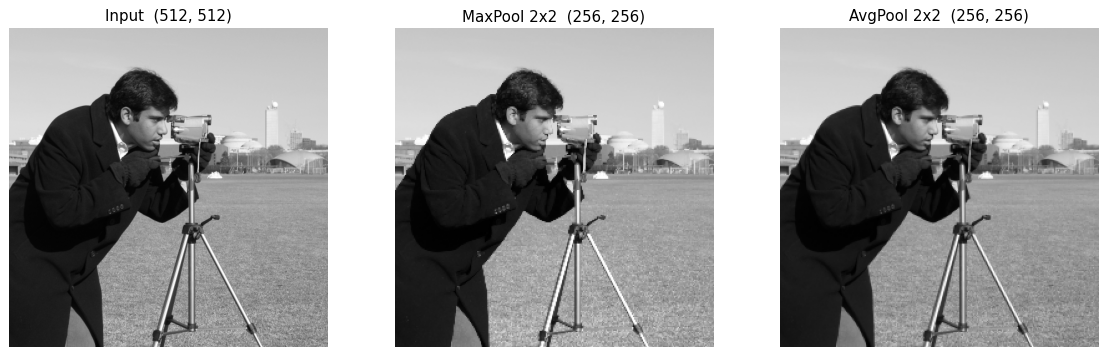

In [ ]:
x = torch.tensor(real, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(f"Input  : {x.shape}")

mp  = F.max_pool2d(x, kernel_size=2, stride=2)
ap  = F.avg_pool2d(x, kernel_size=2, stride=2)
gap = F.adaptive_avg_pool2d(x, output_size=1)

print(f"MaxPool 2x2/2  : {mp.shape}")
print(f"AvgPool 2x2/2  : {ap.shape}")
print(f"GlobalAvgPool  : {gap.shape}  (one scalar per channel — "
      f"value = {gap.item():.4f})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t, title in zip(axes,
                          [x, mp, ap],
                          ['Input', 'MaxPool 2x2', 'AvgPool 2x2']):
    ax.imshow(t.squeeze().numpy(), cmap='gray')
    ax.set_title(f'{title}  {tuple(t.shape[2:])}'); ax.axis('off')
plt.tight_layout(); plt.show()


### 4.2 Activation functions

Without non-linearities, stacking layers would just compose linear maps — the whole network would collapse to a single linear layer, no matter the depth. Activations are what let CNNs learn complex functions.


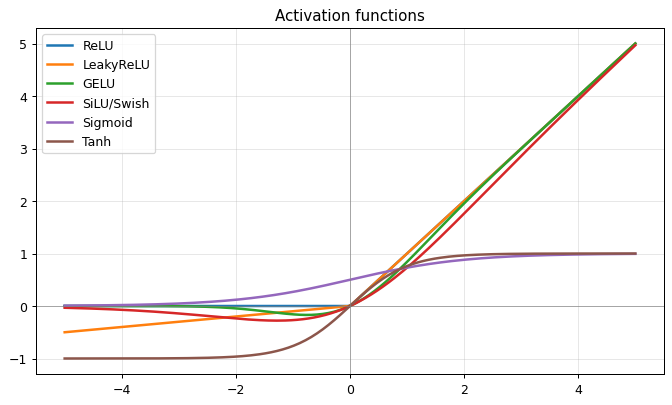

Practical guidance:
  ReLU       : default everywhere, fast, simple, may suffer 'dying ReLU' (outputs stuck at 0)
  LeakyReLU  : fixes dying ReLU by allowing tiny negative slope
  GELU       : smoother ReLU; standard in Transformers (BERT, ViT)
  SiLU/Swish : smoother again; used in EfficientNet, modern vision models
  Sigmoid    : binary classification output / gates (rarely as hidden activation)
  Tanh       : centered around 0, used in old RNNs; rare in modern CNNs


In [ ]:
x = torch.linspace(-5, 5, 200)

acts = {
    'ReLU'      : torch.relu(x),
    'LeakyReLU' : F.leaky_relu(x, negative_slope=0.1),
    'GELU'      : F.gelu(x),
    'SiLU/Swish': F.silu(x),
    'Sigmoid'   : torch.sigmoid(x),
    'Tanh'      : torch.tanh(x),
}

fig, ax = plt.subplots(figsize=(9, 5))
for name, y in acts.items():
    ax.plot(x.numpy(), y.numpy(), label=name, lw=2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.legend(); ax.grid(alpha=0.3); ax.set_title('Activation functions'); plt.show()

print("Practical guidance:")
print("  ReLU       : default everywhere, fast, simple, may suffer 'dying ReLU' (outputs stuck at 0)")
print("  LeakyReLU  : fixes dying ReLU by allowing tiny negative slope")
print("  GELU       : smoother ReLU; standard in Transformers (BERT, ViT)")
print("  SiLU/Swish : smoother again; used in EfficientNet, modern vision models")
print("  Sigmoid    : binary classification output / gates (rarely as hidden activation)")
print("  Tanh       : centered around 0, used in old RNNs; rare in modern CNNs")


### 4.3 Batch Normalization — the workhorse of trainable deep nets

Batch norm normalizes each channel's activations to zero-mean / unit-variance **across the mini-batch**, then re-scales with learnable parameters $\gamma$ and $\beta$:

$$ \hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y = \gamma \hat{x} + \beta $$

**What it buys you:**
1. Lets you use larger learning rates without divergence
2. Reduces dependence on careful initialization
3. Acts as a mild regularizer
4. Critical for deep nets like ResNet to even *train*

**Other normalizations** (used when batch size is small or unavailable):

| Norm | Normalizes over | Use case |
|------|-----------------|----------|
| BatchNorm  | Batch + spatial dims (per channel) | Standard CNNs, batch size ≥ 16 |
| LayerNorm  | All channels + spatial (per sample) | Transformers, ViT, ConvNeXt |
| GroupNorm  | Channel groups + spatial (per sample) | Detection, small batches |
| InstanceNorm | Spatial only (per sample, per channel) | Style transfer |


In [ ]:
# Demonstrate BatchNorm visually: random feature map, before vs after BN
torch.manual_seed(0)
features = torch.randn(8, 4, 16, 16) * 3 + 5  # batch of 8, 4 channels, mean=5 std=3
bn = nn.BatchNorm2d(4)
bn.train()
normalized = bn(features)

print('Before BN — per-channel statistics across the batch:')
for c in range(4):
    print(f'  ch{c}: mean={features[:, c].mean():+.3f}, std={features[:, c].std():.3f}')

print('\nAfter BN — per-channel statistics across the batch:')
for c in range(4):
    print(f'  ch{c}: mean={normalized[:, c].mean():+.3f}, std={normalized[:, c].std():.3f}')

print('\n→ Each channel now has ~0 mean and ~1 std (the gamma/beta start at 1/0).')


Before BN — per-channel statistics across the batch:
  ch0: mean=+4.913, std=2.968
  ch1: mean=+5.127, std=3.032
  ch2: mean=+5.038, std=3.013
  ch3: mean=+4.823, std=3.002

After BN — per-channel statistics across the batch:
  ch0: mean=-0.000, std=1.000
  ch1: mean=-0.000, std=1.000
  ch2: mean=+0.000, std=1.000
  ch3: mean=+0.000, std=1.000

→ Each channel now has ~0 mean and ~1 std (the gamma/beta start at 1/0).


## 5. 🏗️ Putting It Together — A Full CNN Block

A typical CNN building block is:

```
   Input
     │
   Conv2d (k=3, p=1)
     │
   BatchNorm2d
     │
   ReLU
     │
   (sometimes another Conv→BN→ReLU)
     │
   MaxPool2d  (or stride-2 conv)
     │
   Output
```

Let's build this block, run a CIFAR-10-shaped tensor through it, and watch the spatial dimensions shrink and the channels grow.


In [ ]:
class ConvBlock(nn.Module):
    """A standard Conv→BN→ReLU block, optionally followed by max-pool."""
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=True):
        super().__init__()
        # Bias is redundant when followed by BatchNorm — set bias=False to save params
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size,
                               padding=kernel_size // 2, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        return self.pool(self.act(self.bn(self.conv(x))))

# Stack four blocks: 3 -> 32 -> 64 -> 128 -> 256 channels
blocks = nn.Sequential(
    ConvBlock(  3,  32),
    ConvBlock( 32,  64),
    ConvBlock( 64, 128),
    ConvBlock(128, 256, pool=False),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(256, 10),  # 10 classes (CIFAR-10)
)
print(blocks)

# Trace the shape through the network
x = torch.randn(2, 3, 32, 32)
print(f"\n{'Layer':<28} {'Output shape':<25} {'Activations'}")
print('-' * 70)
for name, module in blocks.named_children():
    x = module(x)
    print(f"{name + ' ' + module.__class__.__name__:<28} {str(tuple(x.shape)):<25} {x.numel():>10,}")

n_params = sum(p.numel() for p in blocks.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


Sequential(
  (0): ConvBlock(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): ConvBlock(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (2): ConvBlock(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (3): ConvBlock(
    (conv): 

---
# Part B — Training Fundamentals

A working CNN architecture is only half the battle. *How* you train it — the data, the loss, the optimizer, the schedule — usually matters more than the architecture choice.


## 6. 📊 Datasets: Train / Validation / Test

### Why three splits?

| Split | What it's for | What you do with it |
|-------|---------------|---------------------|
| **Train** | Fit model parameters | Run gradient descent; the model "sees" these samples |
| **Validation** | Tune hyperparameters & pick best epoch | Pick the LR, depth, augmentation strength; early stopping |
| **Test** | Final, honest report of generalization | Measured **once**, at the end. Never used for any decision. |

> ⚠️ **Common mistake**: tuning hyperparameters on the test set. This silently leaks information and produces optimistic numbers that won't replicate in the real world. **Treat the test set as if it doesn't exist until the very end.**

### Typical ratios
- Small datasets (< 10K): 60 / 20 / 20 or use **k-fold CV** instead
- Medium datasets (10K–100K): 70 / 15 / 15 or 80 / 10 / 10
- Large datasets (1M+): 98 / 1 / 1 is fine

We'll use **CIFAR-10** (60K 32×32 color images, 10 classes), which torchvision provides as 50K train + 10K test. We'll carve a validation set out of the train split.


In [ ]:
# Where to store CIFAR-10 (downloads ~170 MB on first run)
DATA_ROOT = './data'
os.makedirs(DATA_ROOT, exist_ok=True)

# Minimal transforms here — just to ToTensor() so we can inspect raw values.
basic_tf = transforms.ToTensor()

train_full = datasets.CIFAR10(DATA_ROOT, train=True,  download=True, transform=basic_tf)
test_set   = datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=basic_tf)

print(f"Train_full size: {len(train_full):,}")
print(f"Test       size: {len(test_set):,}")
print(f"Image shape    : {train_full[0][0].shape}  (C, H, W)")
print(f"Pixel range    : [{train_full[0][0].min():.3f}, {train_full[0][0].max():.3f}]  "
      f"(after ToTensor, values are in [0, 1])")
print(f"Classes        : {train_full.classes}")

# Carve 5,000 samples out of the 50,000 train_full for validation.
# We use a fixed seed so the split is reproducible.
gen = torch.Generator().manual_seed(42)
train_set, val_set = random_split(train_full, [45_000, 5_000], generator=gen)
print(f"\nFinal splits → train: {len(train_set):,}, val: {len(val_set):,}, test: {len(test_set):,}")


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Train_full size: 50,000
Test       size: 10,000
Image shape    : torch.Size([3, 32, 32])  (C, H, W)
Pixel range    : [0.000, 1.000]  (after ToTensor, values are in [0, 1])
Classes        : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Final splits → train: 45,000, val: 5,000, test: 10,000


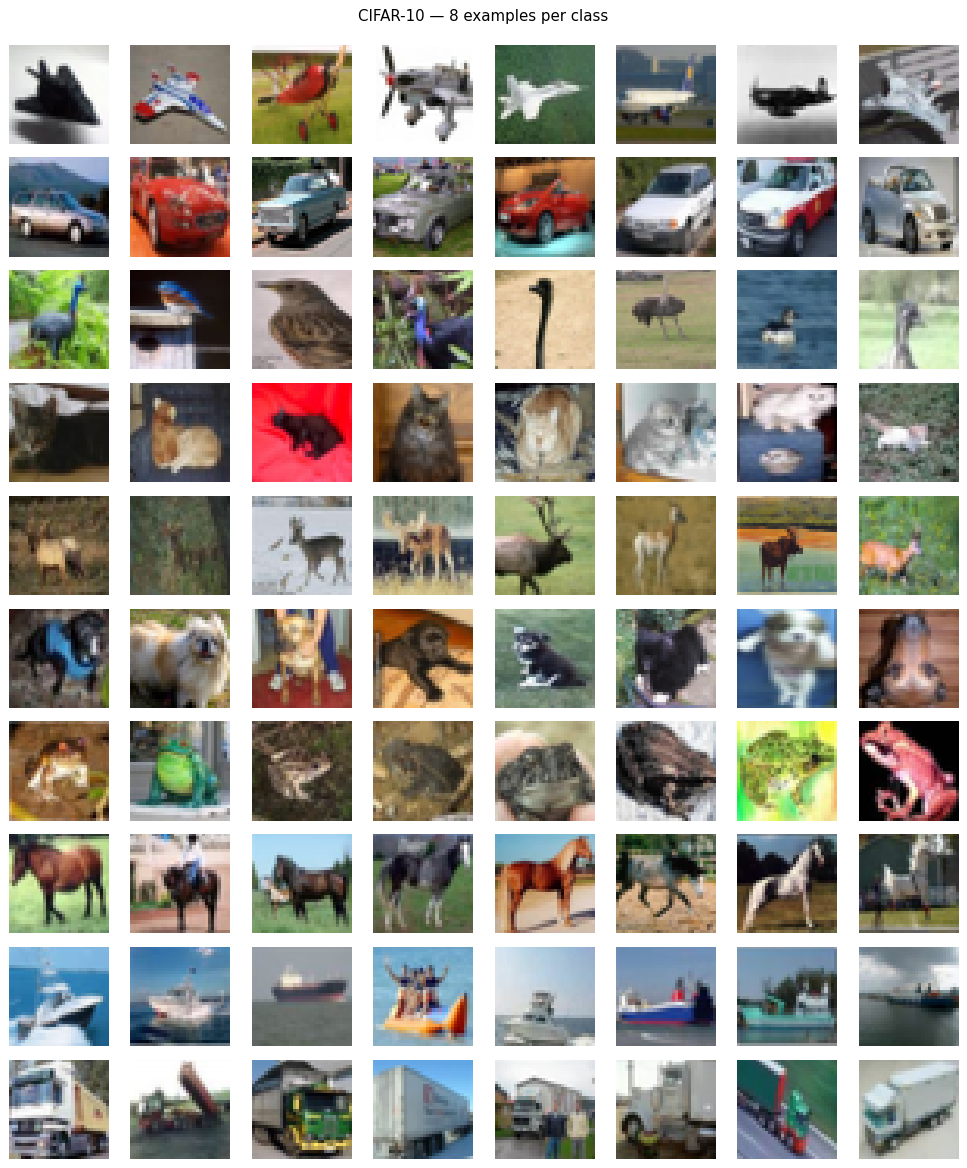

In [ ]:
# Visualize 8 samples per class
fig, axes = plt.subplots(10, 8, figsize=(11, 13))
classes = train_full.classes
class_imgs = {i: [] for i in range(10)}
for img, lbl in train_full:
    if len(class_imgs[lbl]) < 8:
        class_imgs[lbl].append(img)
    if all(len(v) == 8 for v in class_imgs.values()):
        break

for r in range(10):
    for c in range(8):
        axes[r, c].imshow(class_imgs[r][c].permute(1, 2, 0).numpy())
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(classes[r], rotation=0, ha='right', va='center', fontsize=10)

plt.suptitle("CIFAR-10 — 8 examples per class", y=0.995); plt.tight_layout(); plt.show()


## 7. ⚖️ Preprocessing & Normalization

Neural nets train best when inputs are roughly **zero-mean, unit-variance**. There are several flavors of normalization:

| Type | What it does | When to use |
|------|--------------|-------------|
| **`ToTensor()`** | uint8 [0, 255] → float [0, 1] | **Always** — first step |
| **Per-image norm** | Subtract image mean, divide by image std | Rare in classification; common in some self-supervised methods |
| **Per-channel dataset norm** | Subtract dataset's per-channel mean, divide by dataset std | **Default for from-scratch training** |
| **ImageNet stats** | mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] | **When fine-tuning ImageNet pre-trained models** (must match the stats they were trained with!) |

### Why per-channel normalization?

Different channels have different brightness distributions. Normalizing each channel separately makes the input loss landscape more isotropic → optimizer converges faster and to better minima.


In [ ]:
# Compute CIFAR-10's per-channel mean and std on the training set
loader_for_stats = DataLoader(train_set, batch_size=512, shuffle=False, num_workers=2)

mean = torch.zeros(3); std = torch.zeros(3); n_pixels = 0
for x, _ in loader_for_stats:
    # x: (B, 3, 32, 32). Compute pixel mean per channel
    n      = x.size(0) * x.size(2) * x.size(3)
    mean  += x.sum(dim=[0, 2, 3])
    std   += (x ** 2).sum(dim=[0, 2, 3])
    n_pixels += n

mean /= n_pixels
std   = (std / n_pixels - mean ** 2).sqrt()

CIFAR_MEAN = mean.tolist()
CIFAR_STD  = std.tolist()
print(f"CIFAR-10 per-channel mean: {[f'{m:.4f}' for m in CIFAR_MEAN]}")
print(f"CIFAR-10 per-channel std : {[f'{s:.4f}' for s in CIFAR_STD]}")
print('\n(For comparison, the values commonly cited in papers are')
print(' mean ≈ [0.4914, 0.4822, 0.4465], std ≈ [0.2470, 0.2435, 0.2616])')


CIFAR-10 per-channel mean: ['0.4917', '0.4823', '0.4467']
CIFAR-10 per-channel std : ['0.2471', '0.2435', '0.2616']

(For comparison, the values commonly cited in papers are
 mean ≈ [0.4914, 0.4822, 0.4465], std ≈ [0.2470, 0.2435, 0.2616])


Original tensor range : [0.000, 1.000]
Normalized tensor range: [-1.990, 2.094]
After normalization values are roughly in [-2, +2] — NOT [0, 1] anymore.


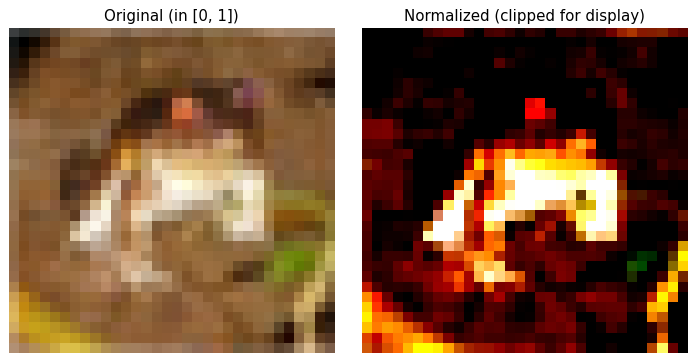

In [ ]:
# Show the visual effect of normalization
sample, _ = train_full[0]
normed = transforms.Normalize(CIFAR_MEAN, CIFAR_STD)(sample)
print(f"Original tensor range : [{sample.min():.3f}, {sample.max():.3f}]")
print(f"Normalized tensor range: [{normed.min():.3f}, {normed.max():.3f}]")
print('After normalization values are roughly in [-2, +2] — NOT [0, 1] anymore.')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample.permute(1, 2, 0).numpy())
axes[0].set_title('Original (in [0, 1])'); axes[0].axis('off')
# clamp for display only — normalized values aren't directly displayable as RGB
axes[1].imshow(normed.permute(1, 2, 0).numpy().clip(0, 1))
axes[1].set_title('Normalized (clipped for display)'); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 8. 🔄 Data Augmentation — Free Generalization

Augmentation = on-the-fly random transformations of training images. Each epoch, the network sees *new* variants of every image — it can't memorize, only learn invariances.

### Classic augmentations

| Transform | Why |
|-----------|-----|
| Random crop (with padding) | Translation invariance |
| Horizontal flip | Mirror invariance (rarely vertical: a flipped car looks weird) |
| Color jitter | Robustness to lighting & color cast |
| Random rotation (small) | Tilt invariance |
| RandomErasing / Cutout | Occlusion robustness |

### Modern augmentations (post-2018)

| Method | Mechanism |
|--------|-----------|
| **Mixup** | Linear blend of two images and their labels |
| **CutMix** | Paste a rectangular patch from another image and mix labels by area |
| **AutoAugment** | RL-searched augmentation policy |
| **RandAugment** | Simpler: pick N augmentations randomly with magnitude M |
| **TrivialAugment** | Even simpler, often just as good |

> 🤖 **Robotics**: training with aggressive augmentation (lighting, blur, motion artifacts, partial occlusions) is **essential** for sim-to-real transfer. The richer your augmentations, the smaller the reality gap.


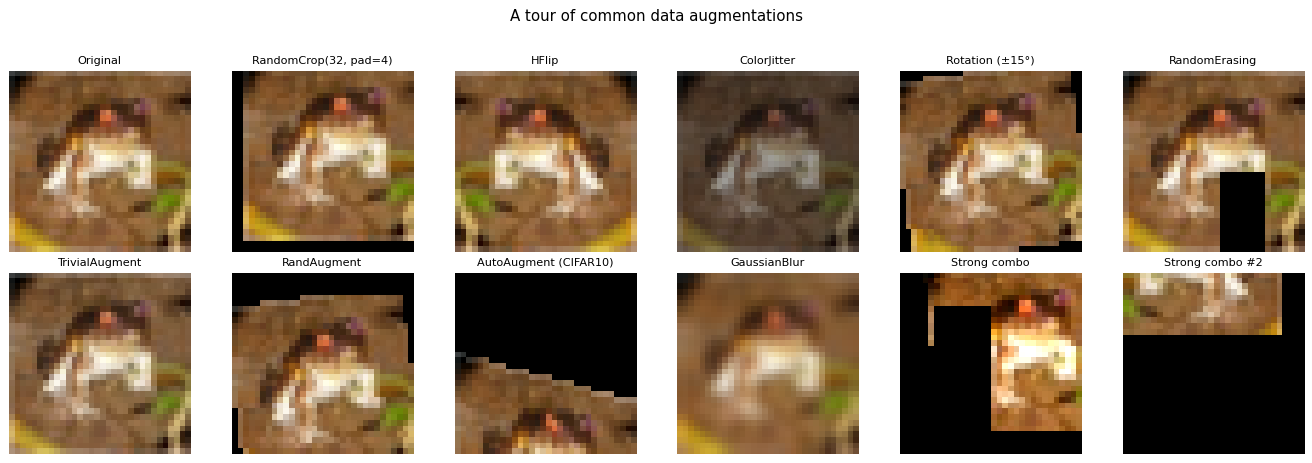

In [ ]:
# Visualize 6 augmentation strategies on a single image
sample_pil = transforms.ToPILImage()(sample)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

augs = [
    ('Original', transforms.Compose([transforms.ToTensor()])),
    ('RandomCrop(32, pad=4)',
        transforms.Compose([transforms.RandomCrop(32, padding=4),
                              transforms.ToTensor()])),
    ('HFlip',
        transforms.Compose([transforms.RandomHorizontalFlip(p=1.0),
                              transforms.ToTensor()])),
    ('ColorJitter',
        transforms.Compose([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
                              transforms.ToTensor()])),
    ('Rotation (±15°)',
        transforms.Compose([transforms.RandomRotation(15),
                              transforms.ToTensor()])),
    ('RandomErasing',
        transforms.Compose([transforms.ToTensor(),
                              transforms.RandomErasing(p=1.0, scale=(0.05, 0.2))])),
    ('TrivialAugment',
        transforms.Compose([transforms.TrivialAugmentWide(),
                              transforms.ToTensor()])),
    ('RandAugment',
        transforms.Compose([transforms.RandAugment(num_ops=2, magnitude=9),
                              transforms.ToTensor()])),
    ('AutoAugment (CIFAR10)',
        transforms.Compose([
            transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
            transforms.ToTensor()])),
    ('GaussianBlur',
        transforms.Compose([transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
                              transforms.ToTensor()])),
    ('Strong combo',
        transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4),
            transforms.RandAugment(),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.3)])),
    ('Strong combo #2',
        transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.TrivialAugmentWide(),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.3)])),
]

for ax, (name, tf) in zip(axes.flat, augs):
    out = tf(sample_pil) if name != 'Original' else sample
    ax.imshow(out.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9); ax.axis('off')

plt.suptitle('A tour of common data augmentations', y=1.02)
plt.tight_layout(); plt.show()


### 8.1 Mixup and CutMix

Both blend pairs of images and labels. They're typically applied at the **batch level** during training. They consistently improve accuracy and calibration.


Mixup λ = 0.009  → blend strength
CutMix λ (area kept from primary) = 0.569


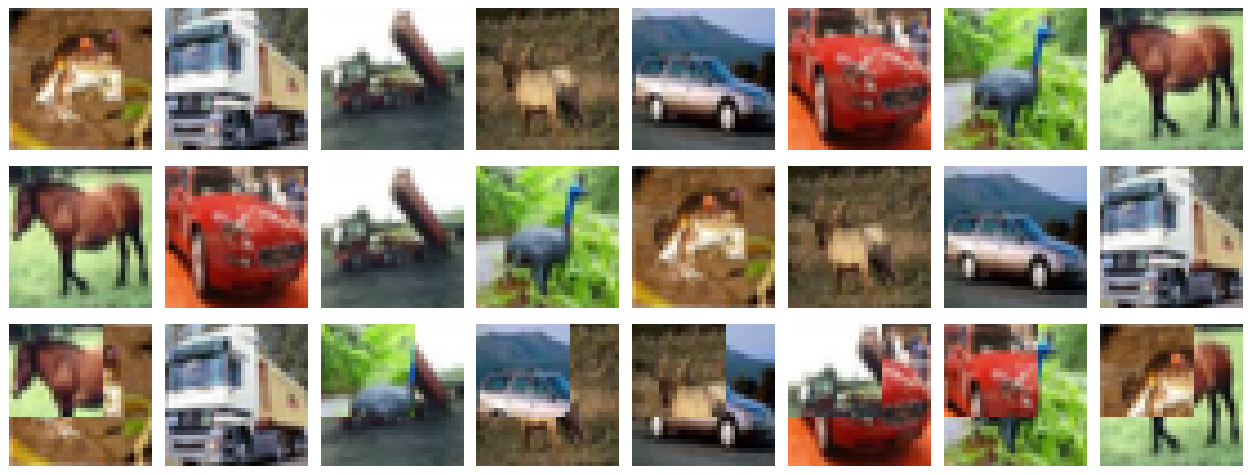

In [ ]:
def mixup(x, y, alpha=0.2):
    """Mixup: x' = λx_a + (1-λ)x_b, target = λy_a + (1-λ)y_b"""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def cutmix(x, y, alpha=1.0):
    """CutMix: paste a random rectangle from another image, mix labels by area."""
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    idx = torch.randperm(B, device=x.device)
    # Random box
    cut_rat = np.sqrt(1.0 - lam)
    cw, ch = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(0, cx - cw // 2), min(W, cx + cw // 2)
    y1, y2 = max(0, cy - ch // 2), min(H, cy + ch // 2)
    x_new = x.clone()
    x_new[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
    return x_new, y, y[idx], lam

# Visualize on a small batch
batch = torch.stack([train_full[i][0] for i in range(8)])
fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))

for c in range(8):
    axes[0, c].imshow(batch[c].permute(1, 2, 0).numpy()); axes[0, c].axis('off')

mx, _, _, lam_mix = mixup(batch, torch.zeros(8))
print(f"Mixup λ = {lam_mix:.3f}  → blend strength")
for c in range(8):
    axes[1, c].imshow(mx[c].permute(1, 2, 0).numpy().clip(0, 1)); axes[1, c].axis('off')

cm, _, _, lam_cut = cutmix(batch, torch.zeros(8))
print(f"CutMix λ (area kept from primary) = {lam_cut:.3f}")
for c in range(8):
    axes[2, c].imshow(cm[c].permute(1, 2, 0).numpy().clip(0, 1)); axes[2, c].axis('off')

axes[0, 0].set_ylabel('Original',  rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('Mixup',     rotation=0, ha='right', va='center')
axes[2, 0].set_ylabel('CutMix',    rotation=0, ha='right', va='center')
plt.tight_layout(); plt.show()


## 9. 🎯 Loss Functions

The loss tells the optimizer what "wrong" means. Pick the right loss for the right task:

| Task | Standard loss |
|------|---------------|
| Multi-class classification (mutually exclusive labels) | **Cross-entropy** |
| Multi-label (multiple positive labels) | **Binary cross-entropy with logits** per class |
| Heavily imbalanced classes | **Focal loss** (down-weights easy examples) |
| Regression (continuous output) | MSE / L1 / SmoothL1 |

### 9.1 Cross-entropy — what's actually happening

For a single sample with ground-truth class $y$ and logits $\mathbf{z}$:

$$ p_i = \text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}, \qquad \mathcal{L} = -\log p_y $$

PyTorch's `nn.CrossEntropyLoss` takes raw **logits** (not softmax outputs) for numerical stability — never `softmax → CE` manually.

### 9.2 Label smoothing — soft targets

Instead of a one-hot target $[0, 0, 1, 0, ...]$, use $[\frac{\epsilon}{K-1}, \frac{\epsilon}{K-1}, 1-\epsilon, \frac{\epsilon}{K-1}, ...]$ for some small $\epsilon$ (e.g., 0.1). This stops the network from becoming over-confident, improves calibration, and often improves accuracy by ~0.1–0.5%.

### 9.3 Focal loss — for imbalanced data

$$ \mathcal{L}_{\text{focal}} = -(1 - p_y)^\gamma \log p_y $$

The factor $(1 - p_y)^\gamma$ down-weights easy examples ($p_y$ close to 1) so the network focuses on hard ones.


In [ ]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional alpha class weighting."""
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma, self.alpha = gamma, alpha
    def forward(self, logits, target):
        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()
        nll   = F.nll_loss(log_p, target, reduction='none')
        pt    = p.gather(1, target.unsqueeze(1)).squeeze(1)
        loss  = (1 - pt) ** self.gamma * nll
        if self.alpha is not None:
            loss = loss * self.alpha[target]
        return loss.mean()

# Toy: 3 classes, batch of 5
torch.manual_seed(0)
logits = torch.randn(5, 3)
target = torch.tensor([0, 1, 2, 1, 0])
print('Logits:'); print(logits)
print(f'\nTargets: {target.tolist()}')

ce      = F.cross_entropy(logits, target).item()
ce_smooth = F.cross_entropy(logits, target, label_smoothing=0.1).item()
focal     = FocalLoss(gamma=2.0)(logits, target).item()

print(f'\nCross-entropy             : {ce:.4f}')
print(f'Cross-entropy + smoothing  : {ce_smooth:.4f}')
print(f'Focal loss (γ=2)           : {focal:.4f}')
print('\n(Smoothing slightly raises CE because perfect confidence is no longer optimal.)')


Logits:
tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986],
        [ 0.4033,  0.8380, -0.7193],
        [-0.4033, -0.5966,  0.1820],
        [-0.8567,  1.1006, -1.0712]])

Targets: [0, 1, 2, 1, 0]

Cross-entropy             : 1.5898
Cross-entropy + smoothing  : 1.5820
Focal loss (γ=2)           : 1.1480

(Smoothing slightly raises CE because perfect confidence is no longer optimal.)


## 10. 🚀 Optimizers

The optimizer turns gradients into parameter updates.

| Optimizer | Update rule (essence) | When to use |
|-----------|----------------------|-------------|
| **SGD** | $\theta \gets \theta - \eta \nabla\mathcal{L}$ | Always works as a baseline |
| **SGD + momentum** | Adds running average of gradients | The classic for training CNNs |
| **Adam** | Adaptive per-parameter LR + momentum | Fast convergence, good default for many tasks |
| **AdamW** | Adam with **decoupled** weight decay | **Modern default**: same speed as Adam, generalizes better |

### 10.1 The "Adam vs SGD" debate

For computer vision specifically:
- **From-scratch training of CNNs**: SGD+momentum often reaches the best final accuracy, especially with a long cosine schedule.
- **Transformers, transfer learning, RL**: AdamW dominates.

### 10.2 Weight decay — what it really does

Weight decay shrinks every parameter slightly toward zero each step:

$$ \theta \gets \theta - \eta (\nabla\mathcal{L} + \lambda \theta) $$

It's an L2 regularizer on the weights. Typical values: $\lambda = 5 \times 10^{-4}$ for SGD, $\lambda = 0.05$ for AdamW.

> **AdamW vs Adam**: Adam couples weight decay into the adaptive denominator and effectively scales it down for parameters with large gradients. AdamW *decouples* weight decay (applies it directly to the weights) — this is what you actually want.


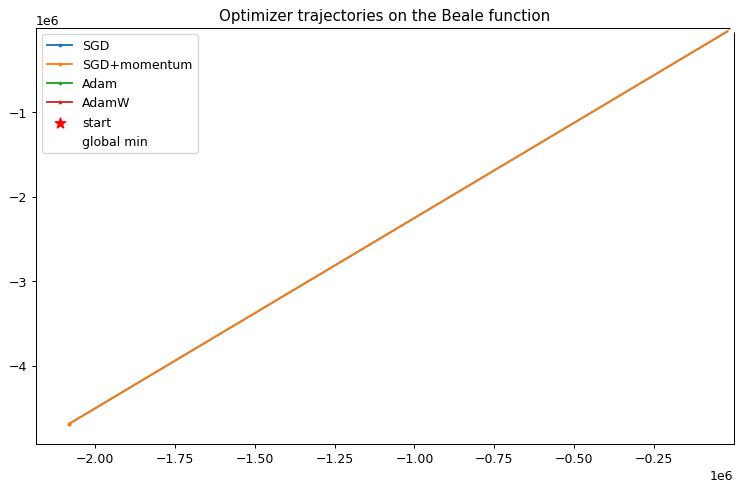

Final positions (target: x=3, y=0.5):
  SGD            (+nan, +nan)  loss=nan
  SGD+momentum   (+nan, +nan)  loss=nan
  Adam           (+0.258, -1.860)  loss=9.4008
  AdamW          (+0.315, -1.619)  loss=9.0230


In [ ]:
# Visualize how three optimizers find the minimum of a non-convex 2D function
def f(p):
    x, y = p[0], p[1]
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2  # Beale

start = torch.tensor([-1.5, -3.0], requires_grad=True)
optimizers = {
    'SGD'         : lambda p: torch.optim.SGD([p], lr=0.005),
    'SGD+momentum': lambda p: torch.optim.SGD([p], lr=0.005, momentum=0.9),
    'Adam'        : lambda p: torch.optim.Adam([p], lr=0.05),
    'AdamW'       : lambda p: torch.optim.AdamW([p], lr=0.05, weight_decay=0.01),
}

paths = {}
for name, make in optimizers.items():
    p = start.detach().clone().requires_grad_(True)
    opt = make(p)
    history = [p.detach().clone().numpy()]
    for _ in range(300):
        opt.zero_grad()
        loss = f(p); loss.backward(); opt.step()
        history.append(p.detach().clone().numpy())
    paths[name] = np.stack(history)

# Plot the loss landscape and the trajectories
xs = np.linspace(-2, 4, 200); ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys)
Z = (1.5 - X + X*Y)**2 + (2.25 - X + X*Y**2)**2 + (2.625 - X + X*Y**3)**2

fig, ax = plt.subplots(figsize=(10, 6))
ax.contourf(X, Y, np.log1p(Z), levels=30, cmap='viridis')
for name, h in paths.items():
    ax.plot(h[:, 0], h[:, 1], '-o', ms=2, lw=1.5, label=name)
ax.scatter(*start.detach().numpy(), c='red', s=80, marker='*', label='start', zorder=5)
ax.scatter(3, 0.5, c='white', s=80, marker='X', label='global min', zorder=5)
ax.legend(); ax.set_title('Optimizer trajectories on the Beale function'); plt.show()

print('Final positions (target: x=3, y=0.5):')
for name, h in paths.items():
    final_loss = f(torch.tensor(h[-1])).item()
    print(f'  {name:<14} ({h[-1, 0]:+.3f}, {h[-1, 1]:+.3f})  loss={final_loss:.4f}')


## 11. 📈 Learning Rate Schedules

A constant LR is rarely optimal:
- **Too high**: training oscillates, may diverge
- **Too low**: slow, gets stuck in poor minima

The standard recipe: **start high, decay over time**.

### Common schedules


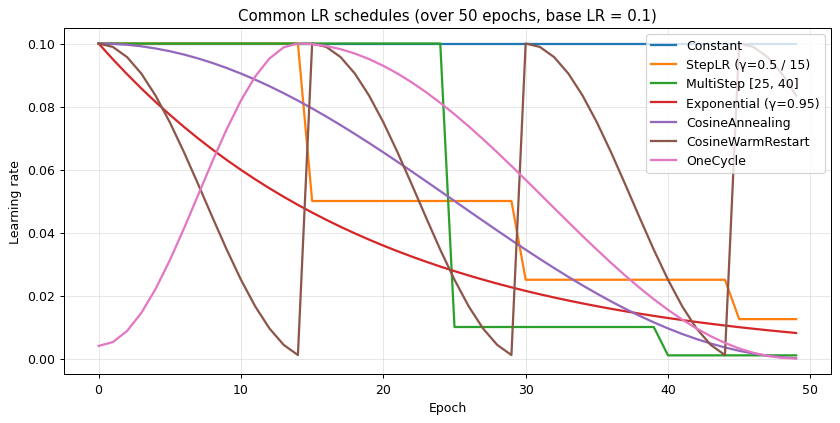

Practical advice:
  - CosineAnnealing       : great default, smooth, no manual milestones
  - OneCycle              : super-convergence; lets you train fast & well
  - StepLR / MultiStepLR  : classical, works fine if tuned
  - Add a warmup of 1-5 epochs for very large models or learning rates


In [ ]:
# Simulate the LR curves of common schedulers over 50 epochs
import torch.optim as optim
N_EPOCHS = 50
dummy = nn.Linear(1, 1)

def trace(scheduler_fn):
    o = optim.SGD(dummy.parameters(), lr=0.1)
    s = scheduler_fn(o)
    lrs = []
    for _ in range(N_EPOCHS):
        lrs.append(o.param_groups[0]['lr'])
        s.step()
    return lrs

schedules = {
    'Constant'              : lambda o: optim.lr_scheduler.LambdaLR(o, lambda e: 1.0),
    'StepLR (γ=0.5 / 15)'   : lambda o: optim.lr_scheduler.StepLR(o, 15, 0.5),
    'MultiStep [25, 40]'    : lambda o: optim.lr_scheduler.MultiStepLR(o, [25, 40], 0.1),
    'Exponential (γ=0.95)'  : lambda o: optim.lr_scheduler.ExponentialLR(o, 0.95),
    'CosineAnnealing'       : lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=N_EPOCHS),
    'CosineWarmRestart'     : lambda o: optim.lr_scheduler.CosineAnnealingWarmRestarts(o, T_0=15, T_mult=1),
    'OneCycle'              : lambda o: optim.lr_scheduler.OneCycleLR(o, max_lr=0.1, total_steps=N_EPOCHS),
}

fig, ax = plt.subplots(figsize=(11, 5))
for name, fn in schedules.items():
    ax.plot(trace(fn), label=name, lw=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate'); ax.legend(loc='upper right')
ax.set_title('Common LR schedules (over 50 epochs, base LR = 0.1)'); ax.grid(alpha=0.3); plt.show()

print('Practical advice:')
print('  - CosineAnnealing       : great default, smooth, no manual milestones')
print('  - OneCycle              : super-convergence; lets you train fast & well')
print('  - StepLR / MultiStepLR  : classical, works fine if tuned')
print('  - Add a warmup of 1-5 epochs for very large models or learning rates')


---
# Part C — Your First CNN, Hyperparameters, Tuning

We've covered the building blocks. Now let's actually train a CNN end-to-end on CIFAR-10, analyze the curves, and use principled methods to tune it.


## 12. 🎓 A Small CNN on CIFAR-10 — End-to-End

We'll build a small but real CNN, train it with proper validation, and analyze the loss/accuracy curves.

### Architecture
- 3 conv blocks (Conv → BN → ReLU → Conv → BN → ReLU → MaxPool) — channels 64 → 128 → 256
- Global average pooling
- Linear classifier

### Training recipe
- AdamW + cosine LR schedule
- Cross-entropy with label smoothing
- Augmentations: RandomCrop(pad=4) + HorizontalFlip


In [ ]:
# === Reusable training utilities ===
class AverageMeter:
    """Tracks running mean of a quantity (loss/accuracy) across mini-batches."""
    def __init__(self): self.reset()
    def reset(self): self.sum = self.count = 0
    def update(self, val, n=1):
        self.sum   += float(val) * n
        self.count += n
    @property
    def avg(self): return self.sum / max(self.count, 1)

def accuracy(logits, target):
    """Top-1 accuracy."""
    return (logits.argmax(dim=1) == target).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    L, A = AverageMeter(), AverageMeter()
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        out  = model(x)
        L.update(criterion(out, y).item(), x.size(0))
        A.update(accuracy(out, y), x.size(0))
    return L.avg, A.avg

def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None,
                     mixup_alpha=0.0, log_every=0):
    model.train()
    L, A = AverageMeter(), AverageMeter()
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        if mixup_alpha > 0:
            x_mix, y_a, y_b, lam = mixup(x, y, mixup_alpha)
            out = model(x_mix)
            loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
        else:
            out  = model(x)
            loss = criterion(out, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if scheduler is not None and not isinstance(scheduler,
                  (optim.lr_scheduler.ReduceLROnPlateau,)):
            scheduler.step()
        L.update(loss.item(), x.size(0))
        A.update(accuracy(out, y), x.size(0))
    return L.avg, A.avg

print("Training utilities defined.")


Training utilities defined.


In [ ]:
# === Build datasets with proper transforms ===
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Use plain-CIFAR10 datasets twice (one with train_tf, one with eval_tf) and
# index them by the same sample indices for a clean train/val split.
train_full_aug = datasets.CIFAR10(DATA_ROOT, train=True,  transform=train_tf, download=False)
train_full_eval = datasets.CIFAR10(DATA_ROOT, train=True, transform=eval_tf, download=False)
test_set        = datasets.CIFAR10(DATA_ROOT, train=False, transform=eval_tf, download=False)

g = torch.Generator().manual_seed(42)
indices = torch.randperm(50_000, generator=g).tolist()
train_idx, val_idx = indices[:45_000], indices[45_000:]
train_set = Subset(train_full_aug,  train_idx)
val_set   = Subset(train_full_eval, val_idx)

# Loaders. num_workers=2 is a good default on Colab.
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                            num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=512, shuffle=False,
                            num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  ({len(train_set):,} samples)")
print(f"Val   batches: {len(val_loader)}    ({len(val_set):,} samples)")
print(f"Test  batches: {len(test_loader)}   ({len(test_set):,} samples)")


Train batches: 351  (45,000 samples)
Val   batches: 10    (5,000 samples)
Test  batches: 20   (10,000 samples)


In [ ]:
# === Define a small CNN ===
class SmallCNN(nn.Module):
    """6-layer CNN for CIFAR-10. Param count ≈ 1.4M."""
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3,    64),    # 32 -> 16
            block(64,  128),   # 16 -> 8
            block(128, 256),   #  8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

seed_everything(42)
model = SmallCNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

# Quick sanity check: a forward pass produces logits of shape (B, 10)
x_demo = torch.randn(2, 3, 32, 32, device=device)
print(f"Sanity forward pass: input {tuple(x_demo.shape)} -> output {tuple(model(x_demo).shape)}")


SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(

In [ ]:
# === Train the small CNN ===
EPOCHS = 15  # bump to 30+ for better numbers; 15 is fine to see clear curves on Colab GPU

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * len(train_loader))

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
print(f"Training {EPOCHS} epochs on {device} ...\n")
print(f"{'Epoch':<6} {'TrLoss':<8} {'TrAcc':<8} {'VaLoss':<8} {'VaAcc':<8} {'LR':<10} {'time/ep':<8}")

for epoch in range(EPOCHS):
    t0 = time.time()
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, scheduler)
    vl, va = evaluate(model, val_loader, criterion, device)
    dt = time.time() - t0

    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);  history['val_acc'].append(va)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    print(f"{epoch+1:<6} {tl:<8.4f} {ta:<8.4f} {vl:<8.4f} {va:<8.4f} "
          f"{history['lr'][-1]:<10.2e} {dt:<.1f}s")

# Final test-set accuracy — measured ONCE
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFINAL TEST  loss: {test_loss:.4f}  |  TEST  acc: {test_acc*100:.2f}%")


Training 15 epochs on cuda ...

Epoch  TrLoss   TrAcc    VaLoss   VaAcc    LR         time/ep 
1      1.6537   0.4580   1.4308   0.5818   2.97e-03   22.9s
2      1.2947   0.6476   1.3478   0.6542   2.87e-03   21.2s
3      1.1445   0.7287   1.1433   0.7200   2.71e-03   22.4s
4      1.0478   0.7731   1.0876   0.7498   2.50e-03   22.6s
5      0.9804   0.8083   1.0498   0.7890   2.25e-03   21.2s
6      0.9269   0.8341   0.9992   0.8080   1.96e-03   22.4s
7      0.8886   0.8510   0.9132   0.8388   1.66e-03   22.6s
8      0.8498   0.8702   0.9249   0.8282   1.34e-03   21.3s
9      0.8189   0.8833   0.8517   0.8668   1.04e-03   22.5s
10     0.7900   0.8982   0.8382   0.8774   7.50e-04   22.6s
11     0.7676   0.9085   0.8113   0.8900   4.96e-04   21.3s
12     0.7496   0.9177   0.8067   0.8890   2.86e-04   22.6s
13     0.7354   0.9241   0.7971   0.8920   1.30e-04   22.5s
14     0.7259   0.9291   0.7924   0.8970   3.28e-05   21.3s
15     0.7197   0.9342   0.7928   0.8956   0.00e+00   22.5s

FINA

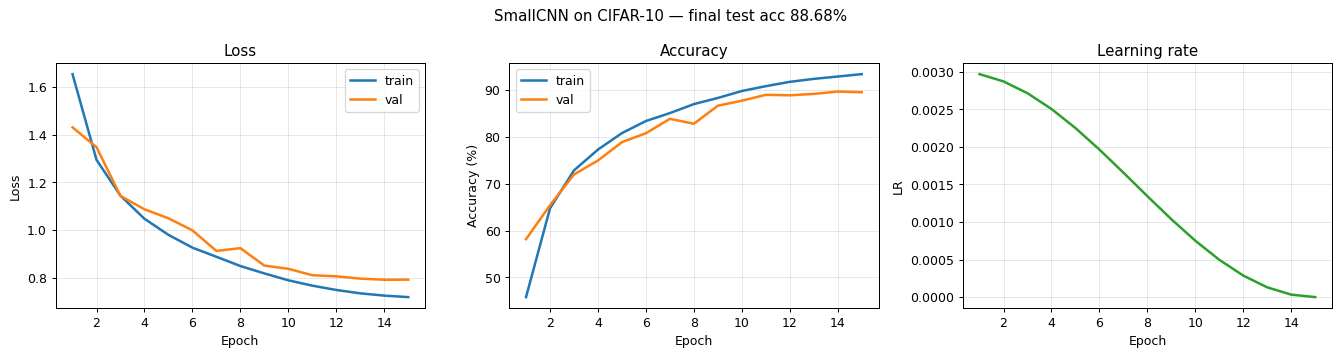

In [ ]:
# === Plot training curves ===
def plot_history(h, title='Training history'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    e = range(1, len(h['train_loss']) + 1)

    axes[0].plot(e, h['train_loss'], label='train', lw=2)
    axes[0].plot(e, h['val_loss'],   label='val',   lw=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(e, [a*100 for a in h['train_acc']], label='train', lw=2)
    axes[1].plot(e, [a*100 for a in h['val_acc']],   label='val',   lw=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(e, h['lr'], lw=2, color='C2')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_title('Learning rate'); axes[2].grid(alpha=0.3)

    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_history(history, title=f'SmallCNN on CIFAR-10 — final test acc {test_acc*100:.2f}%')


### 12.1 How to read these curves

This is *the most important diagnostic skill in deep learning*. The shape of the train and val curves tells you what's wrong:

| Pattern | What it means | What to try |
|---------|---------------|-------------|
| Train and val both decrease, val plateaus | Healthy. Maybe train longer / bigger model. | – |
| Train ↓ val ↑ (gap widens) | **Overfitting**. | More augmentation, dropout, weight decay, smaller model |
| Both stay high & flat | **Underfitting**. | Bigger model, longer training, higher LR |
| Train loss explodes | LR too high or no normalization | Reduce LR, add BN, gradient clipping |
| Val accuracy spikes randomly | Batch-size too small / unstable batches | Larger batch size, longer warmup |
| Train loss looks like noise | Likely dataset bug, label leak | Sanity-check loaders & labels |


## 13. 🎚️ Hyperparameter Taxonomy & Sensitivity

Hyperparameters are everything you set *before* training:

### Architectural
- Depth (number of blocks)
- Width (channels per layer)
- Kernel sizes
- Dropout rate
- Activation function

### Optimization
- Learning rate (the most impactful one)
- Optimizer choice
- Weight decay
- Batch size
- Number of epochs
- LR schedule

### Data
- Augmentation strategy + strength
- Normalization stats
- Mixup/CutMix probability and α

### Regularization
- Label smoothing
- Stochastic depth (modern)
- EMA of weights (modern)

### Sensitivity to LR — the demonstration
Here we'll quickly train the same architecture with three very different learning rates and watch what happens.


Quick LR sensitivity sweep (5 epochs each)...

  LR = 1e-04
    final val acc: 70.02%

  LR = 3e-03
    final val acc: 80.50%

  LR = 3e-01
    final val acc: 10.08%


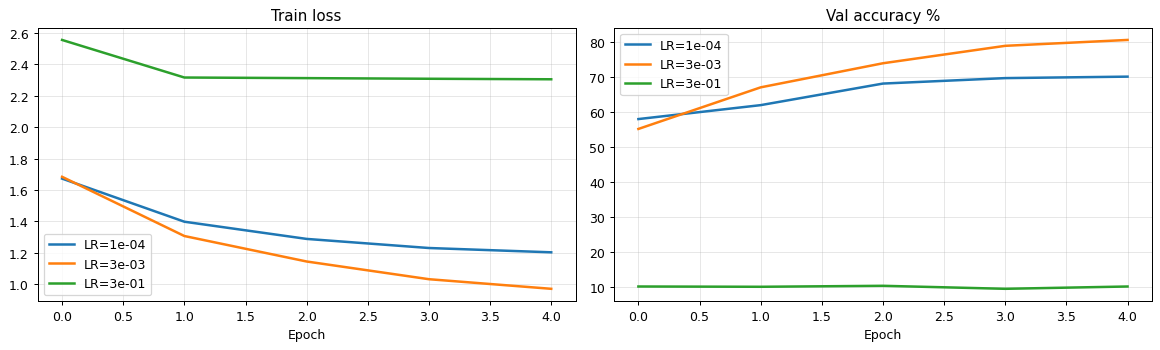


Observe:
  LR=1e-4 (too small): training is slow, val accuracy crawls up
  LR=3e-3 (just right): smooth fast convergence
  LR=3e-1 (too large): loss explodes/oscillates, network does not learn


In [ ]:
# Train SmallCNN with three different LRs for a few epochs each
def quick_train(lr, epochs=5):
    seed_everything(42)
    m = SmallCNN().to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_loader))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    h = {'train_loss': [], 'val_acc': []}
    for ep in range(epochs):
        tl, _ = train_one_epoch(m, train_loader, crit, opt, device, sch)
        _, va = evaluate(m, val_loader, crit, device)
        h['train_loss'].append(tl); h['val_acc'].append(va)
    return h

print('Quick LR sensitivity sweep (5 epochs each)...')
results = {}
for lr in [1e-4, 3e-3, 3e-1]:
    print(f'\n  LR = {lr:.0e}')
    results[lr] = quick_train(lr, epochs=5)
    print(f"    final val acc: {results[lr]['val_acc'][-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lr, h in results.items():
    axes[0].plot(h['train_loss'],         label=f'LR={lr:.0e}', lw=2)
    axes[1].plot([a*100 for a in h['val_acc']], label=f'LR={lr:.0e}', lw=2)
axes[0].set_title('Train loss');     axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val accuracy %'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\nObserve:')
print('  LR=1e-4 (too small): training is slow, val accuracy crawls up')
print('  LR=3e-3 (just right): smooth fast convergence')
print('  LR=3e-1 (too large): loss explodes/oscillates, network does not learn')


## 14. 🔍 Hyperparameter Tuning with Optuna

Manual sweeping is fine for understanding, but to actually find good HPs we want a smarter search method.

### Search strategies

| Method | Idea | Pros / cons |
|--------|------|-------------|
| **Grid search** | Try every combination | Exhaustive but exponentially slow |
| **Random search** | Sample uniformly from each HP range | Often beats grid search at the same budget |
| **Bayesian (TPE)** | Build a model of the loss surface, propose promising points | Sample-efficient, default in Optuna |
| **Hyperband / ASHA** | Aggressively kill bad trials early | Great for large search spaces |
| **Population-based** | Evolve hyperparameters during training | Used at scale (DeepMind) |

[**Optuna**](https://optuna.org) is a clean, popular HP tuning library. It uses TPE (Tree-structured Parzen Estimator) by default and supports pruning (early stopping bad trials).

We'll search over: learning rate, weight decay, dropout, and augmentation strength. To stay within Colab's time budget, **each trial trains for only 4 epochs on a 10K subset** — purely for demonstration. In a real project you'd give each trial ~20-50 epochs on the full data.


In [ ]:
import optuna
from torch.utils.data import Subset

# Smaller fast subset just for the HP search
SEARCH_SAMPLES = 10_000
search_train_idx = train_idx[:int(SEARCH_SAMPLES * 0.9)]
search_val_idx   = train_idx[int(SEARCH_SAMPLES * 0.9):SEARCH_SAMPLES]

def make_loaders(crop_pad):
    """Re-build data loaders for a given crop padding hyperparameter."""
    tf_train = transforms.Compose([
        transforms.RandomCrop(32, padding=crop_pad),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    tr_ds  = Subset(datasets.CIFAR10(DATA_ROOT, train=True, transform=tf_train, download=False),
                    search_train_idx)
    va_ds  = Subset(datasets.CIFAR10(DATA_ROOT, train=True, transform=eval_tf, download=False),
                    search_val_idx)
    return (DataLoader(tr_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True),
            DataLoader(va_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True))

def objective(trial: 'optuna.trial.Trial') -> float:
    # 1. Sample hyperparameters from Optuna
    lr        = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd        = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    dropout   = trial.suggest_float('dropout', 0.0, 0.5)
    crop_pad  = trial.suggest_int('crop_pad', 0, 8)

    seed_everything(0)
    m = SmallCNN(dropout=dropout).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)

    tr_loader, va_loader = make_loaders(crop_pad)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=4 * len(tr_loader))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val = 0.0
    for epoch in range(4):
        train_one_epoch(m, tr_loader, crit, opt, device, sch)
        _, va = evaluate(m, va_loader, crit, device)
        best_val = max(best_val, va)
        # 2. Optuna pruning: kill the trial if it looks unpromising
        trial.report(va, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return best_val

# Run the search — small budget so it finishes fast
N_TRIALS = 12
sampler  = optuna.samplers.TPESampler(seed=42)
pruner   = optuna.pruners.MedianPruner(n_warmup_steps=1)
study    = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Running {N_TRIALS} Optuna trials (each ~4 short epochs)...")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"Total tuning time: {(time.time() - t0)/60:.1f} min")
print(f"\nBest trial:    {study.best_trial.number}")
print(f"Best val acc : {study.best_value*100:.2f}%")
print('Best params  :')
for k, v in study.best_params.items():
    print(f"  {k:<14} = {v}")


[I 2026-05-11 08:09:50,630] A new study created in memory with name: no-name-4f59d2fc-2989-4ea8-a467-b0d8acdff02a


Running 12 Optuna trials (each ~4 short epochs)...
Total tuning time: 3.2 min

Best trial:    6
Best val acc : 64.20%
Best params  :
  lr             = 0.000816845589476017
  weight_decay   = 0.0022673986523780395
  dropout        = 0.09983689107917987
  crop_pad       = 4


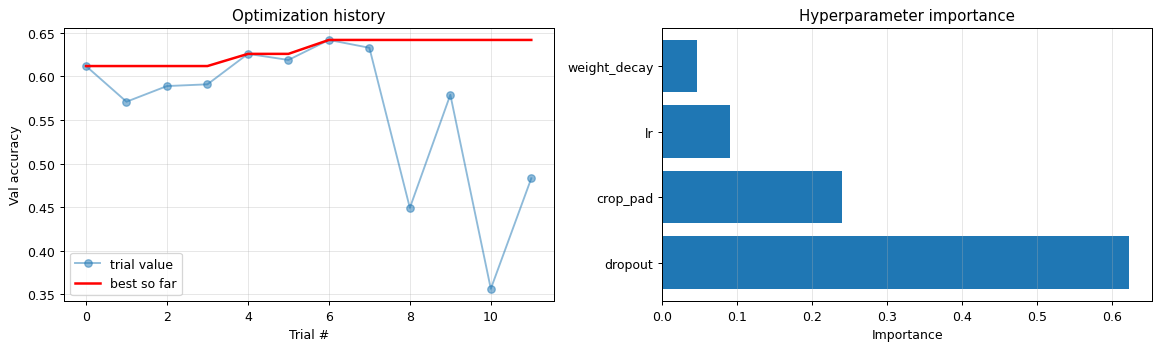

In [ ]:
# Visualize the search
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. Optimization history: best-so-far value over trials
trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)
axes[0].plot(trial_vals,    'o-', alpha=0.5, label='trial value')
axes[0].plot(running_best, 'r-', lw=2, label='best so far')
axes[0].set_xlabel('Trial #'); axes[0].set_ylabel('Val accuracy')
axes[0].set_title('Optimization history'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. Importance of each hyperparameter
try:
    importance = optuna.importance.get_param_importances(study)
    names = list(importance.keys()); vals = list(importance.values())
    axes[1].barh(names, vals)
    axes[1].set_xlabel('Importance'); axes[1].set_title('Hyperparameter importance')
    axes[1].grid(alpha=0.3, axis='x')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importance unavailable\n({e.__class__.__name__})',
                 ha='center', va='center'); axes[1].axis('off')

plt.tight_layout(); plt.show()


## 15. 🔁 K-Fold Cross-Validation

When the dataset is small or you can't afford a fixed validation split, k-fold CV gives a more robust estimate of generalization:

1. Split the training data into **k folds**.
2. For each fold: train on the other k−1 folds, evaluate on this fold.
3. Average the k validation scores.

> ⚠️ **You still keep a separate test set!** K-fold replaces the *single* train/val split, not the test split.

Here we run a 3-fold CV on a 5,000-image subset for speed.


In [ ]:
from sklearn.model_selection import KFold

CV_SAMPLES = 5_000
cv_indices = train_idx[:CV_SAMPLES]
K_FOLDS    = 3
EPOCHS_CV  = 4

# Use NumPy for the index splits, then wrap in PyTorch Subsets
fold_results = []
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

for fold, (tr_pos, va_pos) in enumerate(kf.split(cv_indices)):
    # Map fold positions back to dataset indices
    tr_idx_fold = [cv_indices[i] for i in tr_pos]
    va_idx_fold = [cv_indices[i] for i in va_pos]

    tr_ds = Subset(train_full_aug,  tr_idx_fold)
    va_ds = Subset(train_full_eval, va_idx_fold)
    tr_loader_f = DataLoader(tr_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
    va_loader_f = DataLoader(va_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

    seed_everything(42 + fold)
    m   = SmallCNN().to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_CV * len(tr_loader_f))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)

    print(f"\nFold {fold+1}/{K_FOLDS} — train={len(tr_idx_fold)}, val={len(va_idx_fold)}")
    for ep in range(EPOCHS_CV):
        tl, ta = train_one_epoch(m, tr_loader_f, crit, opt, device, sch)
        vl, va = evaluate(m, va_loader_f, crit, device)
        print(f"  ep {ep+1}: train_acc={ta*100:.2f}%, val_acc={va*100:.2f}%")
    fold_results.append(va)

mean, std = np.mean(fold_results) * 100, np.std(fold_results) * 100
print(f"\n{K_FOLDS}-fold CV val accuracy: {mean:.2f}% ± {std:.2f}%")
print('The standard deviation is your estimate of how much the result depends on the')
print('particular data split — useful when comparing two methods that differ by a small amount.')



Fold 1/3 — train=3333, val=1667
  ep 1: train_acc=23.22%, val_acc=27.47%
  ep 2: train_acc=29.40%, val_acc=32.99%
  ep 3: train_acc=35.25%, val_acc=40.97%
  ep 4: train_acc=38.64%, val_acc=39.29%

Fold 2/3 — train=3333, val=1667
  ep 1: train_acc=21.51%, val_acc=25.19%
  ep 2: train_acc=30.36%, val_acc=31.25%
  ep 3: train_acc=33.54%, val_acc=37.85%
  ep 4: train_acc=38.25%, val_acc=39.95%

Fold 3/3 — train=3334, val=1666
  ep 1: train_acc=21.21%, val_acc=21.49%
  ep 2: train_acc=29.87%, val_acc=32.53%
  ep 3: train_acc=33.98%, val_acc=36.07%
  ep 4: train_acc=37.58%, val_acc=37.70%

3-fold CV val accuracy: 38.98% ± 0.95%
The standard deviation is your estimate of how much the result depends on the
particular data split — useful when comparing two methods that differ by a small amount.


---
# Part D — Classic and Modern Architectures

We've built our own small CNN. Now let's tour the **landmark architectures** that defined the field, building each one and seeing what each innovation actually buys us. We'll wrap up with **Vision Transformers** and **ConvNeXt**, the modern state-of-the-art.

For each architecture we'll show:
- The **historical context** — what problem it solved
- A **clean PyTorch implementation** (or use torchvision's reference)
- **Parameter count, FLOPs, and depth**


In [ ]:
# torchinfo gives us nice model summaries with FLOPs / param counts
from torchinfo import summary

def model_stats(model, input_size=(1, 3, 32, 32)):
    """Return params, MACs (multiply-accumulates), and depth of a model."""
    s = summary(model, input_size=input_size, verbose=0)
    return {
        'params'   : s.total_params,
        'trainable': s.trainable_params,
        'macs'     : s.total_mult_adds,  # roughly = 0.5 * FLOPs
    }


## 16. 🕰️ LeNet → AlexNet → VGG: The Depth Race

### LeNet-5 (LeCun, 1998) — where it all started

The original CNN, designed for handwritten-digit recognition. Two convolutional layers, two pooling layers, two fully-connected layers. ~60K parameters.

### AlexNet (Krizhevsky et al., 2012) — the deep-learning revolution

Won ImageNet 2012 by a *huge* margin (15.3% vs 26.2% top-5 error). Innovations:
- **5 conv layers + 3 FC layers** (deeper than anything practical before)
- **ReLU** activations (vs sigmoid/tanh)
- **Dropout** in FC layers
- **GPU training** (split across 2 GPUs)
- ~60M parameters

### VGG (Simonyan & Zisserman, 2014)

The "stack lots of 3×3 convs" school. Showed that depth alone, with simple uniform building blocks, scales well.
- **All convs are 3×3**; doubling channels at each downsampling stage
- VGG-16 (~138M params) and VGG-19 (~144M params)
- Massive in parameters because of the giant FC layers — most modern nets replaced these with global average pooling


In [ ]:
# Compact LeNet for CIFAR-10 (originally for 28x28 MNIST)
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5), nn.Tanh(), nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5), nn.Tanh(), nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.Tanh(),
            nn.Linear(120, 84),         nn.Tanh(),
            nn.Linear(84, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

# Tiny VGG-style network — useful pattern to know but typically too heavy for CIFAR
class TinyVGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def block(in_c, out_c, n=2):
            layers = []
            for _ in range(n):
                layers += [nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
                in_c = out_c
            layers += [nn.MaxPool2d(2)]
            return nn.Sequential(*layers)
        self.features = nn.Sequential(
            block(3,    64, 2),    # 32 -> 16
            block(64,  128, 2),    # 16 ->  8
            block(128, 256, 3),    #  8 ->  4
            block(256, 512, 3),    #  4 ->  2
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

print('LeNet-5 stats:', model_stats(LeNet5()))
print('TinyVGG stats:', model_stats(TinyVGG()))


LeNet-5 stats: {'params': 62006, 'trainable': 62006, 'macs': 658238}
TinyVGG stats: {'params': 7643082, 'trainable': 7643082, 'macs': 284895498}


## 17. 🌿 Inception and ResNet — Two Architectural Breakthroughs

### Inception (GoogLeNet, 2014)

Instead of asking "**what kernel size should this layer use?**", just use **all of them in parallel** and concatenate the outputs. The *Inception module* applies 1×1, 3×3, 5×5 convs and a max-pool simultaneously, then concatenates them along the channel dimension.

The **1×1 convolution** trick: a 1×1 conv with `in_ch -> out_ch` is just a per-pixel linear map across channels. Used to *cheaply reduce* channel dimension before expensive 3×3 / 5×5 convs.


In [ ]:
class InceptionModule(nn.Module):
    """Simplified Inception block (one of the variants from GoogLeNet)."""
    def __init__(self, in_ch, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_ch, ch1x1, 1), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_ch, ch3x3red, 1), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, 3, padding=1), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_ch, ch5x5red, 1), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, 5, padding=2), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_ch, pool_proj, 1), nn.ReLU(inplace=True))

    def forward(self, x):
        # Concatenate the four branches along the channel dimension
        return torch.cat([self.branch1(x), self.branch2(x),
                          self.branch3(x), self.branch4(x)], dim=1)

mod = InceptionModule(192, 64, 96, 128, 16, 32, 32)
out = mod(torch.randn(1, 192, 28, 28))
print(f"Inception module output shape: {out.shape} (channels = 64+128+32+32 = 256)")
print(f"Parameters: {sum(p.numel() for p in mod.parameters()):,}")


Inception module output shape: torch.Size([1, 256, 28, 28]) (channels = 64+128+32+32 = 256)
Parameters: 163,696


### ResNet (He et al., 2015) — the *most important* architectural innovation

**Problem**: very deep networks (50+ layers) were *worse* than shallow ones, even on the *training* set. The gradients couldn't flow back well enough.

**Solution**: **residual connections** (skip connections). Instead of learning $H(x)$, the network learns the *residual* $F(x) = H(x) - x$, then adds it back: $H(x) = F(x) + x$.

```
            ┌─────────────────────────┐
            │                          ▼
   x ───────┤                          + ──── output
            │                          ▲
            └──► Conv → BN → ReLU ─────┘
                 → Conv → BN
```

**Why it works** (intuition):
- Identity mapping is the "default" — if a block isn't useful, it can learn to output zero and the input passes through unchanged.
- Gradients have a direct highway back to earlier layers (the `+x` is a clean gradient pathway).
- Lets you train **100s or 1000s of layers** stably.

**Every modern architecture uses some form of skip connection.** This single idea is the most impactful in deep learning since the original CNN.


In [ ]:
class BasicBlock(nn.Module):
    """ResNet's basic residual block — for ResNet-18 / ResNet-34."""
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # If shape changes (stride>1 or channel change), shortcut needs a 1x1 conv too
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)         # residual connection
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    """A small ResNet adapted for 32x32 CIFAR images."""
    def __init__(self, block_counts=(2, 2, 2, 2), num_classes=10):
        super().__init__()
        self.in_ch = 64
        # CIFAR variant: 3x3 stem, no early downsample
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64,  block_counts[0], stride=1)
        self.layer2 = self._make_layer(128, block_counts[1], stride=2)
        self.layer3 = self._make_layer(256, block_counts[2], stride=2)
        self.layer4 = self._make_layer(512, block_counts[3], stride=2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, num_classes),
        )

    def _make_layer(self, ch, n_blocks, stride):
        layers = [BasicBlock(self.in_ch, ch, stride)]
        self.in_ch = ch
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(ch, ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.head(x)

resnet = ResNetCIFAR()
print('ResNet-18 (CIFAR variant) stats:', model_stats(resnet))

# Print the layer structure
for n, m in resnet.named_children():
    print(f"  {n:<10}: {m.__class__.__name__}")


ResNet-18 (CIFAR variant) stats: {'params': 11173962, 'trainable': 11173962, 'macs': 555432330}
  stem      : Sequential
  layer1    : Sequential
  layer2    : Sequential
  layer3    : Sequential
  layer4    : Sequential
  head      : Sequential


### 17.1 Train ResNet vs SmallCNN — what does depth + skip connections buy us?

We'll train both architectures with the *exact same* recipe and compare. (Short run for time; bump the epochs to see the gap widen.)


In [ ]:
def full_train(model, epochs, name, lr=3e-3, wd=5e-4):
    """Full training loop with cosine schedule, returns history + final test acc."""
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_loader))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    h = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    print(f"\n{name}: training {epochs} epochs ...")
    for ep in range(epochs):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, crit, opt, device, sch)
        vl, va = evaluate(model, val_loader, crit, device)
        h['train_loss'].append(tl); h['train_acc'].append(ta)
        h['val_loss'].append(vl);   h['val_acc'].append(va)
        print(f"  ep {ep+1:2d}: tr_loss={tl:.3f} tr_acc={ta*100:5.2f}% "
              f"va_acc={va*100:5.2f}% ({time.time() - t0:.1f}s)")
    _, test_acc = evaluate(model, test_loader, crit, device)
    h['test_acc'] = test_acc
    print(f"  TEST ACCURACY: {test_acc*100:.2f}%")
    return h

EPOCHS_COMPARE = 12   # adjust upward (~25-30) for tighter results

seed_everything(42)
hist_smallcnn = full_train(SmallCNN().to(device), EPOCHS_COMPARE, 'SmallCNN')

seed_everything(42)
hist_resnet   = full_train(ResNetCIFAR().to(device), EPOCHS_COMPARE, 'ResNet-18 (CIFAR)')



SmallCNN: training 12 epochs ...
  ep  1: tr_loss=1.685 tr_acc=43.83% va_acc=55.38% (21.0s)
  ep  2: tr_loss=1.315 tr_acc=63.90% va_acc=67.54% (19.8s)
  ep  3: tr_loss=1.161 tr_acc=71.93% va_acc=70.68% (20.9s)
  ep  4: tr_loss=1.056 tr_acc=77.09% va_acc=75.26% (19.9s)
  ep  5: tr_loss=0.983 tr_acc=80.73% va_acc=79.84% (21.2s)
  ep  6: tr_loss=0.928 tr_acc=83.22% va_acc=80.04% (20.0s)
  ep  7: tr_loss=0.887 tr_acc=85.11% va_acc=83.86% (20.9s)
  ep  8: tr_loss=0.848 tr_acc=87.15% va_acc=84.98% (21.0s)
  ep  9: tr_loss=0.818 tr_acc=88.57% va_acc=87.56% (19.9s)
  ep 10: tr_loss=0.795 tr_acc=89.61% va_acc=87.82% (21.3s)
  ep 11: tr_loss=0.778 tr_acc=90.36% va_acc=88.60% (20.0s)
  ep 12: tr_loss=0.771 tr_acc=90.79% va_acc=88.54% (21.0s)
  TEST ACCURACY: 87.88%

ResNet-18 (CIFAR): training 12 epochs ...
  ep  1: tr_loss=1.830 tr_acc=37.70% va_acc=49.14% (44.8s)
  ep  2: tr_loss=1.453 tr_acc=56.18% va_acc=62.76% (44.5s)
  ep  3: tr_loss=1.240 tr_acc=66.87% va_acc=66.90% (44.8s)
  ep  4: tr_lo

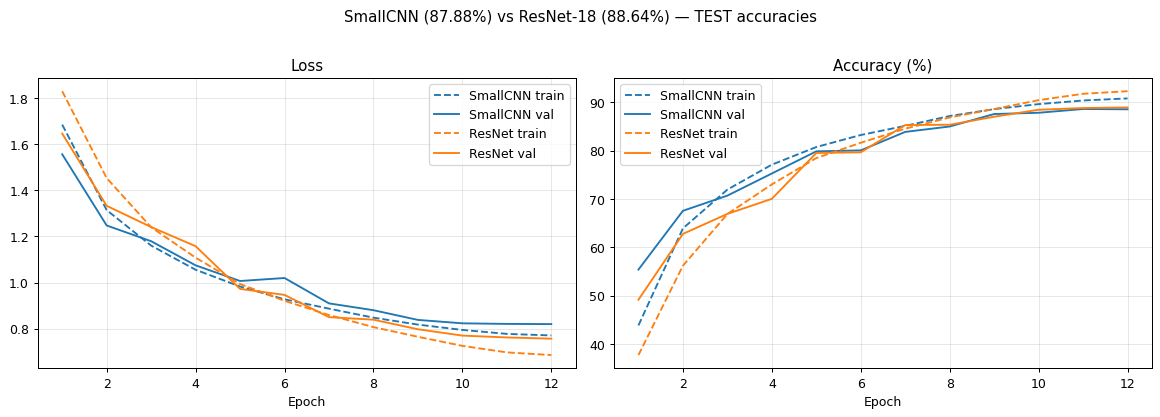

SmallCNN — params:  1,148,874, test acc: 87.88%
ResNet-18 — params: 11,173,962, test acc: 88.64%


In [ ]:
# Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
e = range(1, EPOCHS_COMPARE + 1)

axes[0].plot(e, hist_smallcnn['train_loss'], '--', color='C0', label='SmallCNN train')
axes[0].plot(e, hist_smallcnn['val_loss'],   '-',  color='C0', label='SmallCNN val')
axes[0].plot(e, hist_resnet['train_loss'],   '--', color='C1', label='ResNet train')
axes[0].plot(e, hist_resnet['val_loss'],     '-',  color='C1', label='ResNet val')
axes[0].set_title('Loss');     axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e, [a*100 for a in hist_smallcnn['train_acc']], '--', color='C0', label='SmallCNN train')
axes[1].plot(e, [a*100 for a in hist_smallcnn['val_acc']],   '-',  color='C0', label='SmallCNN val')
axes[1].plot(e, [a*100 for a in hist_resnet['train_acc']],   '--', color='C1', label='ResNet train')
axes[1].plot(e, [a*100 for a in hist_resnet['val_acc']],     '-',  color='C1', label='ResNet val')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'SmallCNN ({hist_smallcnn["test_acc"]*100:.2f}%) vs ResNet-18 '
              f'({hist_resnet["test_acc"]*100:.2f}%) — TEST accuracies', y=1.02)
plt.tight_layout(); plt.show()

print(f"SmallCNN — params: {sum(p.numel() for p in SmallCNN().parameters()):>10,}, "
      f"test acc: {hist_smallcnn['test_acc']*100:.2f}%")
print(f"ResNet-18 — params: {sum(p.numel() for p in ResNetCIFAR().parameters()):>10,}, "
      f"test acc: {hist_resnet['test_acc']*100:.2f}%")


## 18. 🪶 DenseNet, MobileNet, EfficientNet — Beyond ResNet

### DenseNet (Huang et al., 2017)

Take ResNet's skip connections to the extreme: **every layer in a block receives input from all preceding layers**. Concatenation instead of addition.
- Encourages feature reuse → fewer parameters than ResNet at similar accuracy.
- Tradeoff: high memory due to keeping all intermediate features.

### MobileNet (Howard et al., 2017) — designed for phones and robots

Replaces every standard 3×3 conv with a **depthwise-separable convolution**:
1. **Depthwise** conv: each input channel gets its own 3×3 filter (no cross-channel mixing). Cheap.
2. **Pointwise** (1×1) conv: mixes channels. Also cheap.

A standard 3×3 conv with $C_{in} = C_{out} = 64$ costs $64 \cdot 64 \cdot 9 = 36{,}864$ params per spatial output. The depthwise+pointwise version costs $64 \cdot 9 + 64 \cdot 64 = 576 + 4096 = 4{,}672$ — **8× fewer**. The accuracy drop is small.

> 🤖 **Robotics relevance**: MobileNet variants are *the* default backbones on embedded robots (Raspberry Pi, Jetson Nano, drones). Trade a few % accuracy for 5-10× speed.

### EfficientNet (Tan & Le, 2019)

Asks: **how should we scale up a CNN?** Their answer: scale depth, width, and input resolution *jointly*, with carefully balanced ratios — a "compound scaling rule". Achieves state-of-the-art ImageNet accuracy with far fewer parameters than its predecessors.

EfficientNetV2 (2021) refined this with progressive resizing and Fused-MBConv blocks for faster training.


In [ ]:
# Demonstrate the depthwise-separable speedup
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # 1) Depthwise: groups=in_ch means each input channel is convolved separately
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        # 2) Pointwise 1x1 mixes channels
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))))

# Param-count comparison
std = nn.Conv2d(64, 128, 3, padding=1, bias=False)
sep = DepthwiseSeparableConv(64, 128)
print(f"Standard 3x3 conv 64->128 : {sum(p.numel() for p in std.parameters()):>8,} params")
print(f"Depthwise-separable 64->128: {sum(p.numel() for p in sep.parameters()):>8,} params")

# Use the official torchvision implementations to compare
print('\n=== Param counts of well-known ImageNet backbones (untrained skeletons) ===')
print(f"{'Model':<25} {'Params':>15} {'Notes'}")
print('-' * 75)
for name, fn in [
    ('AlexNet',          models.alexnet),
    ('VGG-11',           models.vgg11),
    ('ResNet-18',        models.resnet18),
    ('ResNet-50',        models.resnet50),
    ('DenseNet-121',     models.densenet121),
    ('MobileNetV2',      models.mobilenet_v2),
    ('MobileNetV3-Small',models.mobilenet_v3_small),
    ('EfficientNet-B0',  models.efficientnet_b0),
    ('ConvNeXt-Tiny',    models.convnext_tiny),
]:
    m = fn(weights=None)
    p = sum(x.numel() for x in m.parameters())
    print(f"{name:<25} {p:>15,}")


Standard 3x3 conv 64->128 :   73,728 params
Depthwise-separable 64->128:    9,024 params

=== Param counts of well-known ImageNet backbones (untrained skeletons) ===
Model                              Params Notes
---------------------------------------------------------------------------
AlexNet                        61,100,840
VGG-11                        132,863,336
ResNet-18                      11,689,512
ResNet-50                      25,557,032
DenseNet-121                    7,978,856
MobileNetV2                     3,504,872
MobileNetV3-Small               2,542,856
EfficientNet-B0                 5,288,548
ConvNeXt-Tiny                  28,589,128


---
# Part E — Practical Workflows

The "modern way" to train an image classifier in 2025:

> **Don't train from scratch.** Take a model pre-trained on ImageNet (or larger) and fine-tune it for your task. You'll get vastly better results with 100× less data.


## 19. 🔄 Transfer Learning & Fine-Tuning

The pre-trained features from a model trained on ImageNet are an excellent starting point for **almost any natural-image task**: medical imaging, robotics perception, drone footage, you name it.

### Three modes of transfer learning

| Mode | What you do | When to use |
|------|-------------|-------------|
| **Feature extraction** | Freeze backbone, train only a new classifier head | Tiny dataset, limited compute |
| **Fine-tuning** | Train everything end-to-end, but with a small LR | Standard recommendation |
| **Differential LRs** | Lower LR for backbone, higher LR for new head | Best of both worlds |

### Practical recipe (most cases)

1. Load `model = torchvision.models.resnet18(weights='DEFAULT')`.
2. Replace the final FC layer to match your number of classes.
3. Use the **same preprocessing as ImageNet** (mean / std).
4. Train end-to-end with a small LR (e.g., 1e-3 with AdamW, or 1e-2 with SGD).


In [ ]:
# Load ResNet-18 pre-trained on ImageNet
pretrained = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(f"Original final FC layer: {pretrained.fc}")

# Replace the final FC layer for 10 classes (CIFAR-10)
n_features = pretrained.fc.in_features
pretrained.fc = nn.Linear(n_features, 10)
print(f"Replaced final FC layer: {pretrained.fc}")

# CIFAR is 32x32 but ImageNet models expect 224x224.
# The ResNet-18 stem is too aggressive for 32x32 (stride-2 7x7 + maxpool destroys spatial info).
# Two options: (a) replace the stem (best), or (b) upsample inputs to 224x224 (slower).
# We'll upsample for simplicity since this is the standard textbook approach.

imagenet_train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])
imagenet_eval_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Build smaller subsets for speed (transfer learning is data-efficient anyway!)
TL_SAMPLES = 5_000
tl_train_idx = train_idx[:TL_SAMPLES - 500]
tl_val_idx   = train_idx[TL_SAMPLES - 500:TL_SAMPLES]

tl_train_set = Subset(datasets.CIFAR10(DATA_ROOT, train=True, transform=imagenet_train_tf, download=False), tl_train_idx)
tl_val_set   = Subset(datasets.CIFAR10(DATA_ROOT, train=True, transform=imagenet_eval_tf,  download=False), tl_val_idx)
tl_test_set  = datasets.CIFAR10(DATA_ROOT, train=False, transform=imagenet_eval_tf, download=False)

tl_train_loader = DataLoader(tl_train_set, batch_size=64,  shuffle=True, num_workers=2, pin_memory=True)
tl_val_loader   = DataLoader(tl_val_set,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
tl_test_loader  = DataLoader(tl_test_set,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTransfer-learning subset: train={len(tl_train_set)}, val={len(tl_val_set)}, test={len(tl_test_set)}")
print(f"Note: we're using only {TL_SAMPLES:,} training images to highlight the data efficiency of transfer learning.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Original final FC layer: Linear(in_features=512, out_features=1000, bias=True)
Replaced final FC layer: Linear(in_features=512, out_features=10, bias=True)

Transfer-learning subset: train=4500, val=500, test=10000
Note: we're using only 5,000 training images to highlight the data efficiency of transfer learning.


In [ ]:
# === Mode A: feature extraction (freeze backbone) ===
seed_everything(42)
model_feat = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_feat.parameters():
    p.requires_grad = False                   # freeze everything ...
model_feat.fc = nn.Linear(model_feat.fc.in_features, 10)  # ... except a fresh head
model_feat = model_feat.to(device)

n_train = sum(p.numel() for p in model_feat.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_feat.parameters())
print(f"Feature-extraction mode: {n_train:,} / {n_total:,} params trainable "
      f"({100*n_train/n_total:.2f}%)")

opt_feat  = torch.optim.AdamW(model_feat.fc.parameters(), lr=1e-3, weight_decay=1e-4)
crit      = nn.CrossEntropyLoss()
EPOCHS_TL = 3
print(f"\nFeature extraction — training only the head for {EPOCHS_TL} epochs...")
hist_feat = {'val_acc': []}
for ep in range(EPOCHS_TL):
    t0 = time.time()
    train_one_epoch(model_feat, tl_train_loader, crit, opt_feat, device)
    _, va = evaluate(model_feat, tl_val_loader, crit, device)
    hist_feat['val_acc'].append(va)
    print(f"  ep {ep+1}: val_acc={va*100:.2f}%  ({time.time() - t0:.1f}s)")

_, feat_test_acc = evaluate(model_feat, tl_test_loader, crit, device)
print(f"Feature extraction TEST accuracy: {feat_test_acc*100:.2f}%")


Feature-extraction mode: 5,130 / 11,181,642 params trainable (0.05%)

Feature extraction — training only the head for 3 epochs...
  ep 1: val_acc=62.00%  (11.9s)
  ep 2: val_acc=72.20%  (11.6s)
  ep 3: val_acc=71.40%  (11.7s)
Feature extraction TEST accuracy: 71.34%


In [ ]:
# === Mode B: full fine-tuning ===
seed_everything(42)
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 10)
model_ft = model_ft.to(device)

# Differential learning rates: smaller LR on the backbone, bigger LR on the head
backbone_params = [p for n, p in model_ft.named_parameters() if not n.startswith('fc.')]
head_params     = list(model_ft.fc.parameters())
opt_ft = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params,     'lr': 1e-3},
], weight_decay=1e-4)
sch_ft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=EPOCHS_TL * len(tl_train_loader))

print(f"Fine-tuning — training EVERYTHING for {EPOCHS_TL} epochs...")
hist_ft = {'val_acc': []}
for ep in range(EPOCHS_TL):
    t0 = time.time()
    train_one_epoch(model_ft, tl_train_loader, crit, opt_ft, device, sch_ft)
    _, va = evaluate(model_ft, tl_val_loader, crit, device)
    hist_ft['val_acc'].append(va)
    print(f"  ep {ep+1}: val_acc={va*100:.2f}%  ({time.time() - t0:.1f}s)")

_, ft_test_acc = evaluate(model_ft, tl_test_loader, crit, device)
print(f"Fine-tuning TEST accuracy: {ft_test_acc*100:.2f}%")

# Compare with from-scratch (small CNN trained on the same subset for the same epochs)
print('\n=== Summary on the small subset (5000 images) ===')
print(f"  Feature extraction (head-only): {feat_test_acc*100:.2f}%  -- fastest, fewest params")
print(f"  Full fine-tuning              : {ft_test_acc*100:.2f}%  -- highest accuracy")
print(f"  (For comparison, our SmallCNN trained from scratch on full 45K reached "
      f"{hist_smallcnn['test_acc']*100:.2f}%)")
print('\nKey insight: transfer learning lets you reach high accuracy with FAR less data.')


Fine-tuning — training EVERYTHING for 3 epochs...
  ep 1: val_acc=81.40%  (17.3s)
  ep 2: val_acc=88.60%  (16.3s)
  ep 3: val_acc=88.80%  (16.3s)
Fine-tuning TEST accuracy: 89.34%

=== Summary on the small subset (5000 images) ===
  Feature extraction (head-only): 71.34%  -- fastest, fewest params
  Full fine-tuning              : 89.34%  -- highest accuracy
  (For comparison, our SmallCNN trained from scratch on full 45K reached 87.88%)

Key insight: transfer learning lets you reach high accuracy with FAR less data.


## 20. 🗺️ t-SNE — Visualizing What the Network Has Learned

A trained classifier maps each image to a feature vector (the layer just before the final classifier). We can ask: **does the network's feature space cluster images by class?**

**t-SNE** (t-distributed Stochastic Neighbor Embedding) projects high-dimensional feature vectors to 2D while preserving local neighborhood structure. If similar images end up near each other in 2D, the features are "good".

> 📌 **What t-SNE is and isn't**: It preserves *local* structure, not global. Distances between far-apart clusters are not meaningful. It's purely for visualization and exploratory analysis — **never** train downstream models on t-SNE output.


Feature matrix: shape=(10000, 512) (10,000 images, 512-dim each)
Running t-SNE on 2000 samples (this can take ~30 s)...
t-SNE done in 19.8s


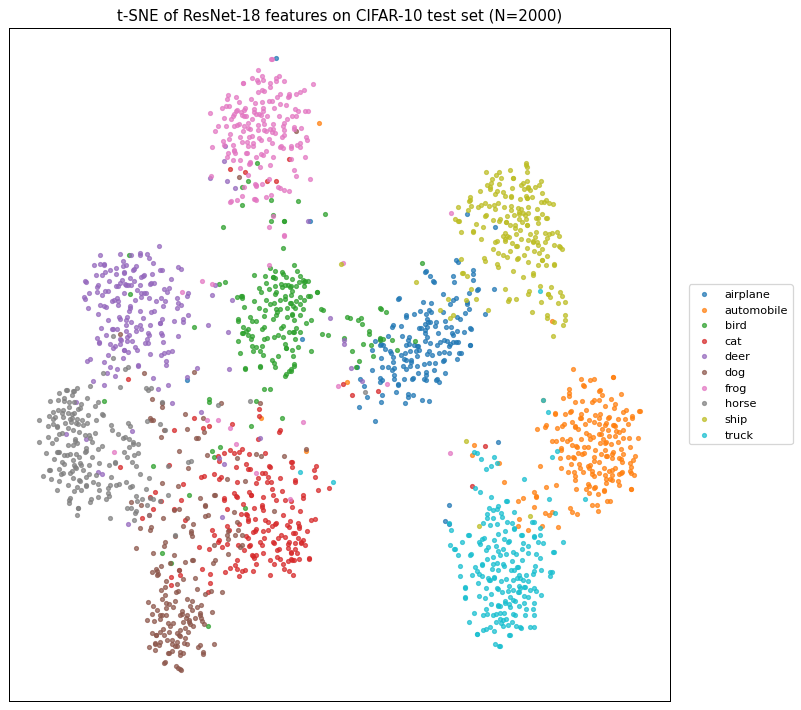


If training went well, you should see ~10 clear clusters, one per class.
Confused classes (e.g. cat vs dog) often partially overlap — that is also informative.


In [ ]:
from sklearn.manifold import TSNE

# Hook into the layer just before fc to grab features
features = []
def hook(module, inp, out):
    features.append(inp[0].detach().cpu())   # the input to fc IS the post-GAP feature

# Use the fine-tuned ResNet for nicer features
model_ft.eval()
handle = model_ft.fc.register_forward_hook(hook)

labels_list = []
with torch.no_grad():
    for x, y in tl_test_loader:
        _ = model_ft(x.to(device))
        labels_list.append(y)

handle.remove()

feat_mat = torch.cat(features).numpy()
labels   = torch.cat(labels_list).numpy()
print(f"Feature matrix: shape={feat_mat.shape} ({feat_mat.shape[0]:,} images, "
      f"{feat_mat.shape[1]}-dim each)")

# t-SNE on a subset for speed
N_TSNE = 2000
sel = np.random.RandomState(0).choice(len(feat_mat), N_TSNE, replace=False)
print(f"Running t-SNE on {N_TSNE} samples (this can take ~30 s)...")
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=0, init='pca', learning_rate='auto')
emb = tsne.fit_transform(feat_mat[sel])
print(f"t-SNE done in {time.time() - t0:.1f}s")

# Plot
fig, ax = plt.subplots(figsize=(9, 8))
class_names = train_full.classes
for c in range(10):
    mask = labels[sel] == c
    ax.scatter(emb[mask, 0], emb[mask, 1], s=10, alpha=0.7, label=class_names[c])
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.set_title(f't-SNE of ResNet-18 features on CIFAR-10 test set (N={N_TSNE})')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print('\nIf training went well, you should see ~10 clear clusters, one per class.')
print('Confused classes (e.g. cat vs dog) often partially overlap — that is also informative.')


## 21. 🔥 Grad-CAM — Which Pixels Did the Network Look At?

Even when a CNN gets the right answer, you might wonder: **was it for the right reasons?** A network that classifies "snowboarder" by detecting snow is brittle (think: photo of a snowy mountain with no snowboarder).

**Grad-CAM** (Gradient-weighted Class Activation Mapping) produces a **heatmap** showing which pixels were most important for the predicted class.

### How it works (one-paragraph version)

1. Forward pass — get the score $y^c$ for class $c$.
2. Backward pass — compute $\frac{\partial y^c}{\partial A^k}$ where $A^k$ is the $k$-th feature map of the last conv layer.
3. Average the gradient over space → channel weights $\alpha^c_k$.
4. Heatmap = ReLU(weighted sum of feature maps with $\alpha^c_k$).

### Why it matters

- **Debug**: model is "right for the wrong reasons" (Clever-Hans effect)
- **Trust**: medical / safety-critical applications need to be explainable
- **Robotics**: ensures your robot's grasp predictor is looking at the *object*, not the gripper or the table


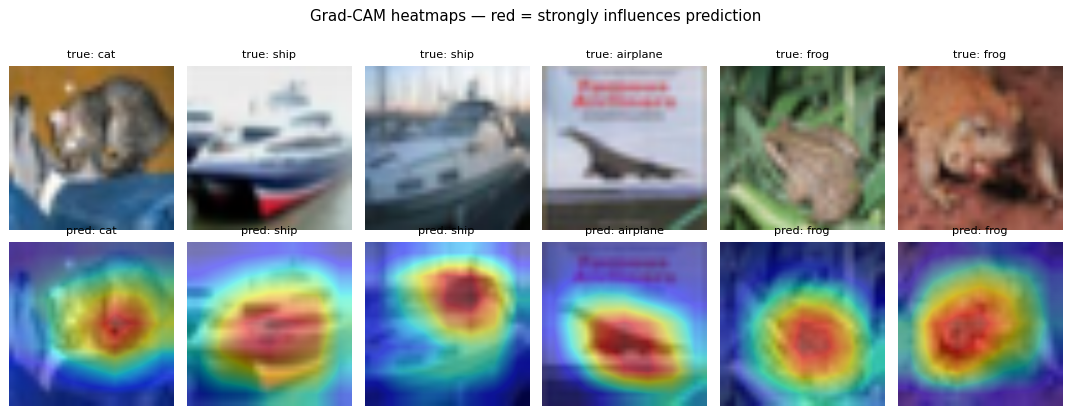

Read these honestly: if the red region is the object, the network is "looking" correctly.
If the red region is the background, you have a clever-Hans problem.


In [ ]:
# Implement Grad-CAM from scratch — short and educational
class GradCAM:
    """Grad-CAM heatmaps for a single target conv layer."""
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.activations = self.gradients = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()
    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        """x: (1, C, H, W) tensor; returns (heatmap[H, W] in [0,1], predicted_class)."""
        self.model.zero_grad()
        out = self.model(x)
        if class_idx is None:
            class_idx = int(out.argmax(dim=1).item())
        score = out[0, class_idx]
        score.backward(retain_graph=False)

        # alpha_k = global average of dY/dA_k over space
        alpha = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (alpha * self.activations).sum(dim=1).squeeze(0)
        cam = F.relu(cam)
        # Normalize to [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        # Resize to input
        cam = F.interpolate(cam.unsqueeze(0).unsqueeze(0),
                             size=x.shape[-2:], mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx

# The last conv layer of ResNet-18 is layer4
gradcam = GradCAM(model_ft, model_ft.layer4)

# Pick a few test images and overlay the heatmap
N_SHOW = 6
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2*N_SHOW, 4.5))
ds_iter = iter(tl_test_loader)
imgs, lbls = next(ds_iter)
for i in range(N_SHOW):
    x = imgs[i:i+1].to(device)
    heatmap, pred = gradcam(x)
    img_disp = (imgs[i] * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)
    axes[0, i].imshow(img_disp)
    axes[0, i].set_title(f"true: {class_names[lbls[i]]}", fontsize=9); axes[0, i].axis('off')
    axes[1, i].imshow(img_disp)
    axes[1, i].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[1, i].set_title(f"pred: {class_names[pred]}", fontsize=9); axes[1, i].axis('off')

plt.suptitle('Grad-CAM heatmaps — red = strongly influences prediction', y=1.02)
plt.tight_layout(); plt.show()

print('Read these honestly: if the red region is the object, the network is "looking" correctly.')
print('If the red region is the background, you have a clever-Hans problem.')


## 22. ⏱️ Inference Benchmarking — Latency, Throughput, FLOPs

For deployment (especially on robots), accuracy isn't the only metric. You also care about:

| Metric | What it measures | Why it matters |
|--------|------------------|----------------|
| **Latency** | Time for one inference | Real-time control loops (≤ 20 ms for 50 Hz robotics) |
| **Throughput** | Inferences per second | Batch-processed video streams |
| **FLOPs / MACs** | Number of operations | Theoretical compute requirement |
| **Parameters** | Memory footprint | Fitting on device (Jetson Nano: ~ 4 GB RAM) |

### How to benchmark *correctly*

1. **Warm up** — first inference is slow (kernel compilation, memory allocation)
2. **Synchronize the GPU** — `torch.cuda.synchronize()` — otherwise you measure async kernel launch only
3. **Average over many runs** — single-shot timing is noisy
4. Use the **same batch size** as deployment


In [ ]:
def benchmark(model, input_size=(1, 3, 32, 32), n_warmup=20, n_runs=100):
    """Return mean latency (ms), throughput (samples/s), and total params for `model`."""
    model = model.to(device).eval()
    x = torch.randn(*input_size, device=device)

    # Warm-up
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Time many runs
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    latency_ms = (elapsed / n_runs) * 1000
    throughput = (n_runs * input_size[0]) / elapsed
    params = sum(p.numel() for p in model.parameters())
    macs = model_stats(model, input_size)['macs']
    return dict(latency_ms=latency_ms, throughput=throughput, params=params, macs=macs)

bench_models = [
    ('SmallCNN (ours)',    SmallCNN(),                                       (1, 3, 32, 32)),
    ('ResNet-18 (CIFAR)',  ResNetCIFAR(),                                    (1, 3, 32, 32)),
    ('ResNet-18 (TV)',     models.resnet18(weights=None, num_classes=10),    (1, 3, 224, 224)),
    ('MobileNetV3-Small',  models.mobilenet_v3_small(weights=None, num_classes=10), (1, 3, 224, 224)),
    ('EfficientNet-B0',    models.efficientnet_b0(weights=None, num_classes=10),    (1, 3, 224, 224)),
]

results = []
print(f"{'Model':<22} {'Input':<14} {'Params':>12} {'MACs':>14} {'Latency(ms)':>12} {'Throughput(/s)':>15}")
print('-' * 95)
for name, m, sz in bench_models:
    r = benchmark(m, sz, n_warmup=10, n_runs=50)
    results.append((name, sz, r))
    print(f"{name:<22} {str(sz[1:]):<14} {r['params']:>12,} {r['macs']:>14,} "
          f"{r['latency_ms']:>12.2f} {r['throughput']:>15.1f}")


Model                  Input                Params           MACs  Latency(ms)  Throughput(/s)
-----------------------------------------------------------------------------------------------
SmallCNN (ours)        (3, 32, 32)       1,148,874    152,768,778         0.85          1169.6
ResNet-18 (CIFAR)      (3, 32, 32)      11,173,962    555,432,330         3.60           277.9
ResNet-18 (TV)         (3, 224, 224)    11,181,642  1,813,576,074         4.10           243.9
MobileNetV3-Small      (3, 224, 224)     1,528,106     55,512,674         6.07           164.6
EfficientNet-B0        (3, 224, 224)     4,020,358    384,598,918        14.38            69.5


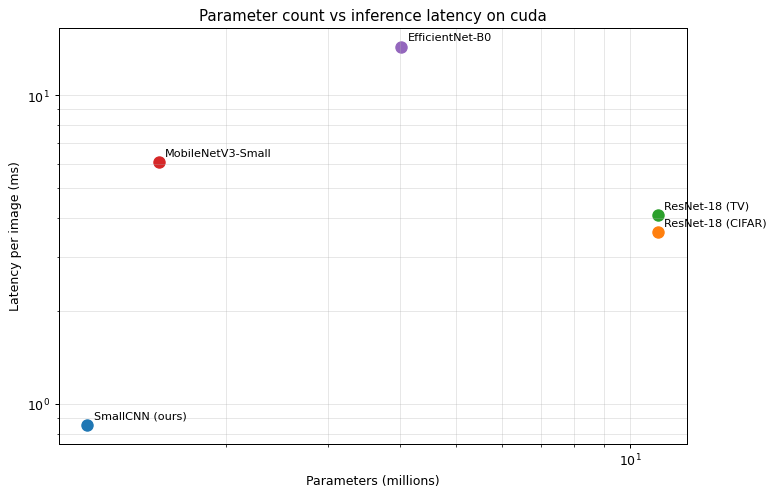

Tradeoff intuition (rough):
  - More params  = larger memory footprint, but not always slower
  - More MACs    = more compute, usually slower (depends on hardware)
  - For robotics targets, prefer MobileNet/EfficientNet-B0 unless you have a GPU


In [ ]:
# Plot the params-vs-latency tradeoff
fig, ax = plt.subplots(figsize=(9, 6))
for name, sz, r in results:
    ax.scatter(r['params'] / 1e6, r['latency_ms'], s=80)
    ax.annotate(name, (r['params'] / 1e6, r['latency_ms']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Parameters (millions)'); ax.set_ylabel('Latency per image (ms)')
ax.set_title(f'Parameter count vs inference latency on {device}')
ax.grid(alpha=0.3, which='both'); plt.show()

print('Tradeoff intuition (rough):')
print('  - More params  = larger memory footprint, but not always slower')
print('  - More MACs    = more compute, usually slower (depends on hardware)')
print('  - For robotics targets, prefer MobileNet/EfficientNet-B0 unless you have a GPU')


## 23. 💡 Best Practices, Common Pitfalls, and Robotics/CV Applications

### 🛠️ Engineering best practices

| Practice | Why |
|----------|-----|
| **Set seeds** at the top of every experiment | Reproducibility |
| **Use `set_to_none=True`** in `optimizer.zero_grad()` | Faster, lower memory |
| **`pin_memory=True`** in `DataLoader` (with CUDA) | Faster H2D transfers |
| **`non_blocking=True`** when calling `.to(device)` | Overlaps with compute |
| **Mixed-precision training** (`torch.amp.autocast`) | 2× faster on modern GPUs, ~half memory |
| **`model.train()` / `model.eval()`** | BatchNorm and Dropout behave differently |
| **`@torch.no_grad()`** during evaluation | No gradient buffers → less memory, faster |
| **Save best checkpoint by val metric**, not final | Avoid overfit-stopping |
| **Log everything** (W&B, TensorBoard, CSV) | Track experiments |
| **Profile before optimizing** (`torch.profiler`) | Don't guess where the bottleneck is |


In [ ]:
# === Mixed-precision training example ===
# PyTorch 2.x recommends torch.amp over torch.cuda.amp
from torch.amp import autocast, GradScaler

def train_one_epoch_amp(model, loader, criterion, optimizer, device, scheduler=None):
    """Same loop, but with autocast + GradScaler (mixed precision)."""
    model.train()
    scaler = GradScaler('cuda', enabled=device.type == 'cuda')
    L, A = AverageMeter(), AverageMeter()
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=device.type == 'cuda'):
            out = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        L.update(loss.item(), x.size(0))
        A.update(accuracy(out, y), x.size(0))
    return L.avg, A.avg

# Time-compare 2 epochs with and without AMP
print('Benchmarking AMP vs FP32 (2 epochs) ...')
for amp_mode, fn in [('FP32', train_one_epoch),
                       ('AMP ', train_one_epoch_amp)]:
    seed_everything(0)
    m = SmallCNN().to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    t0 = time.time()
    for _ in range(2):
        fn(m, train_loader, crit, opt, device)
    print(f"  {amp_mode}: {time.time() - t0:.1f}s for 2 epochs")


Benchmarking AMP vs FP32 (2 epochs) ...
  FP32: 54.6s for 2 epochs
  AMP : 38.4s for 2 epochs


### 🚨 Common pitfalls

1. **Forgetting `model.eval()`** during validation → BatchNorm uses batch stats from val data, which may be different from train → wildly fluctuating val accuracy.
2. **Data leak**: validation transforms accidentally include random augmentation, or test images appear in training set.
3. **Wrong normalization stats**: using ImageNet stats for from-scratch CIFAR training (or vice versa).
4. **Class imbalance ignored**: train loss looks fine but model just predicts the majority class. Use focal loss or `WeightedRandomSampler`.
5. **LR schedulers stepping at the wrong frequency**: per-batch (e.g., OneCycle) vs per-epoch (StepLR).
6. **In-place ops on tensors that require grad**: weird `RuntimeError`s. Use `.clone()` if unsure.
7. **`nn.CrossEntropyLoss` after `softmax`**: the loss expects raw logits, not probabilities.
8. **Tiny batches with BatchNorm**: BN's batch statistics are unreliable below ~16 samples → use GroupNorm or LayerNorm.


### 🤖 Robotics & CV — putting it all together

| Task | Recommended approach |
|------|----------------------|
| **Object recognition for grasping** | Fine-tune EfficientNet-B0 / MobileNetV3 on your objects; use Grad-CAM to verify the model focuses on the object |
| **Place recognition for SLAM loop closure** | Use a pre-trained ResNet's penultimate-layer features as descriptors; nearest-neighbor search in the feature space |
| **Defect classification on assembly line** | Strong augmentation (lighting, blur, perspective) + small ResNet/MobileNet, trained from scratch on your domain |
| **Terrain classification on legged robots** | MobileNetV3-Small for on-board inference; train with heavy augmentation to handle camera shake / motion blur |
| **Gesture recognition for HRI** | Pre-trained CNN backbone + small temporal head, fine-tuned on a small in-domain dataset |
| **Sim-to-real transfer** | Domain randomization (heavy augmentation in simulation) + fine-tune briefly on a tiny real-world dataset |
| **On-device deployment** | Convert to ONNX, then to TensorRT (NVIDIA) or Core ML (Apple) for 5-20× speedup |

### When to choose what

- **CIFAR-scale data, training from scratch**: ResNet-18/34 with strong augmentation.
- **A few hundred to a few thousand images**: fine-tune a pre-trained ResNet or EfficientNet.
- **Massive data (millions)**: try a Vision Transformer (DeiT, Swin, ViT).
- **Constrained latency / battery**: MobileNetV3 / EfficientNet-Lite.
- **Maximum accuracy regardless of cost**: ConvNeXt-Large or a large ViT (or better, ensemble several).

### What's next?

- **Self-supervised learning** (MAE, DINOv2): pre-train on huge unlabeled image collections.
- **Foundation models** (CLIP, SAM): one model that handles many vision tasks via prompting / zero-shot inference.
- **Robust training** (adversarial, certified) for safety-critical robotics.


---
# 🎓 Wrap Up

You've now seen the **complete pipeline of modern image classification with CNNs**:

✅ The convolution operator from scratch — and why it works
✅ The mechanics of strides, padding, dilation, receptive fields
✅ Pooling, activations, BatchNorm and friends
✅ Train / val / test discipline and proper data splits
✅ Preprocessing, normalization, classic & modern augmentations (Mixup, CutMix, RandAugment)
✅ Loss functions (cross-entropy, label smoothing, focal)
✅ Optimizers (SGD/momentum, Adam, AdamW) and LR schedules
✅ Building, training, and analyzing a real CNN end-to-end
✅ Hyperparameter tuning with Optuna
✅ K-fold cross-validation
✅ Landmark architectures: LeNet, AlexNet, VGG, Inception, ResNet, DenseNet, MobileNet, EfficientNet, ViT, ConvNeXt
✅ Transfer learning & fine-tuning
✅ t-SNE for feature-space visualization
✅ Grad-CAM for explainability
✅ Inference benchmarking & deployment trade-offs
✅ Best practices, common pitfalls, robotics applications

### Take-away mental model

> A CNN is a **stack of learned convolutional filters**, organized into a hierarchical feature pyramid.
> Training is **gradient descent on a well-chosen loss**, with regularization (augmentation, weight decay, dropout).
> Modern accuracy comes from **good architectures + smart training recipes**, not just raw depth.
> For real applications, **transfer learning beats from-scratch** training in 95% of cases.

Happy training! 🚀
